In [ ]:
#cell 0-dataset download
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kukulauren/cms-desynpuf-2010-outpatient-claims")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cms-desynpuf-2010-outpatient-claims' dataset.
Path to dataset files: /kaggle/input/cms-desynpuf-2010-outpatient-claims


# Phase one

## **Stage One**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 1: Import libraries and set random seed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Preferred base directory (Colab + Drive)
PREFERRED_BASE_DIR = "/content/drive/MyDrive/Anomaly_Det/outputs"

# Choose base dir based on existence
BASE_DIR = PREFERRED_BASE_DIR if os.path.exists(PREFERRED_BASE_DIR) else FALLBACK_BASE_DIR

PHASE1_OUT = os.path.join(BASE_DIR, "phase1")
PHASE2_OUT = os.path.join(BASE_DIR, "phase2")
PHASE3_OUT = os.path.join(BASE_DIR, "phase3")

# Create directories
os.makedirs(os.path.join(PHASE1_OUT, "data"), exist_ok=True)
os.makedirs(os.path.join(PHASE1_OUT, "plots"), exist_ok=True)
os.makedirs(os.path.join(PHASE2_OUT, "data"), exist_ok=True)
os.makedirs(os.path.join(PHASE2_OUT, "models"), exist_ok=True)
os.makedirs(os.path.join(PHASE2_OUT, "metrics"), exist_ok=True)
os.makedirs(PHASE3_OUT, exist_ok=True)

# Sanity check
print("BASE_DIR:", BASE_DIR)
print("Directories created:")
print(os.path.join(PHASE1_OUT, "data"))
print(os.path.join(PHASE1_OUT, "plots"))
print(os.path.join(PHASE2_OUT, "data"))
print(os.path.join(PHASE2_OUT, "models"))
print(os.path.join(PHASE2_OUT, "metrics"))
print(PHASE3_OUT)

BASE_DIR: /content/drive/MyDrive/Anomaly_Det/outputs
Directories created:
/content/drive/MyDrive/Anomaly_Det/outputs/phase1/data
/content/drive/MyDrive/Anomaly_Det/outputs/phase1/plots
/content/drive/MyDrive/Anomaly_Det/outputs/phase2/data
/content/drive/MyDrive/Anomaly_Det/outputs/phase2/models
/content/drive/MyDrive/Anomaly_Det/outputs/phase2/metrics
/content/drive/MyDrive/Anomaly_Det/outputs/phase3


In [ ]:
#Cell 2: Load dataset and confirm structure
df = pd.read_csv('/kaggle/input/cms-desynpuf-2010-outpatient-claims/desynpuf_outpatient_claims_2010_filtered.csv')
df.columns = df.columns.str.strip()
print(f"Shape: {df.shape}")
print(f"Columns: {df.shape[1]}")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/cms-desynpuf-2010-outpatient-claims/desynpuf_outpatient_claims_2010_filtered.csv'

In [ ]:
# Cell 3: Grain confirmation checks
# Check CLM_ID uniqueness
n_unique_clm = df['CLM_ID'].nunique() if 'CLM_ID' in df.columns else 0
# Number of duplicated CLM_ID values (rows beyond unique)
clm_dup_rows = df['CLM_ID'].duplicated().sum() if 'CLM_ID' in df.columns else 0
# Check SEGMENT variety
n_unique_seg = df['SEGMENT'].nunique() if 'SEGMENT' in df.columns else None
# Check DESYNPUF_ID repetition
n_unique_ben = df['DESYNPUF_ID'].nunique() if 'DESYNPUF_ID' in df.columns else 0
ben_dup_rows = df['DESYNPUF_ID'].duplicated().sum() if 'DESYNPUF_ID' in df.columns else 0
print(f"Distinct CLM_ID: {n_unique_clm}")
print(f"Duplicate CLM_ID rows: {clm_dup_rows}")
print(f"Distinct SEGMENT: {n_unique_seg}")
print(f"Distinct DESYNPUF_ID: {n_unique_ben}")
print(f"Duplicate DESYNPUF_ID rows: {ben_dup_rows}")
# Save grain confirmation to centralized outputs
output_dir = os.path.join(PHASE1_OUT)
os.makedirs(output_dir, exist_ok=True)
report_path = os.path.join(output_dir, 'grain_confirmation_report.txt')
with open(report_path, 'w') as f:
  f.write("Grain: One row = one claim\n")
  f.write(f"CLM_ID unique: {clm_dup_rows == 0}\n")
  seg_const = (n_unique_seg == 1) if (n_unique_seg is not None) else 'N/A'
  f.write(f"SEGMENT constant: {seg_const}\n")
  f.write(f"DESYNPUF_ID repeats: {ben_dup_rows > 0}\n")

Distinct CLM_ID: 175005
Duplicate CLM_ID rows: 0
Distinct SEGMENT: 1
Distinct DESYNPUF_ID: 54794
Duplicate DESYNPUF_ID rows: 120211


In [ ]:
# Cell 4: Number of rows and columns
num_rows, num_cols = df.shape
print(f"Rows: {num_rows}, Columns: {num_cols}")
summary = pd.DataFrame({
  "Column": df.columns,
  "Data Type": df.dtypes.values,
  "Non-Null Count": df.notnull().sum().values,
  "Null Count": df.isnull().sum().values,
  "Percent Missing": (df.isnull().mean() * 100).values
})
unique_claims = df["CLM_ID"].nunique() if 'CLM_ID' in df.columns else 0
print(f"Unique claims (grain at CLM_ID level): {unique_claims}")
if 'SEGMENT' in df.columns:
  segment_counts = df["SEGMENT"].value_counts().sort_index()
  print("Number of rows per segment:\n", segment_counts)
else:
  print("SEGMENT column not present; skipping segment counts")
table1 = summary.copy()
table1.loc['Total'] = ['-', '-', num_rows, int(df.isnull().sum().sum()), '-']
table1

NameError: name 'df' is not defined

In [ ]:
df.describe()

,CLM_ID,SEGMENT,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,AT_PHYSN_NPI,OP_PHYSN_NPI,OT_PHYSN_NPI,NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,ICD9_PRCDR_CD_1,ICD9_PRCDR_CD_6,NCH_BENE_PTB_DDCTBL_AMT,NCH_BENE_PTB_COINSRNC_AMT,HCPCS_CD_45
count,1.750050e+05,175005.0,175005.000000,175005.000000,1.749510e+05,3.071100e+04,9.498800e+04,175005.000000,45.000000,5.000000,175005.000000,175005.000000,0.0
mean,5.425029e+14,1.0,278.593297,8.867918,4.976513e+09,4.993627e+09,4.905460e+09,0.008571,6284.044444,26375.200000,3.034199,81.208423,NaN
std,2.856822e+11,0.0,560.317965,199.751233,2.876214e+09,2.894417e+09,2.889798e+09,1.772770,3226.302161,33124.684288,17.522852,176.867119,NaN
min,5.420123e+14,1.0,-100.000000,0.000000,1.024080e+05,1.053861e+06,1.024080e+05,0.000000,309.000000,2724.000000,0.000000,0.000000,NaN
25%,5.422523e+14,1.0,40.000000,0.000000,2.519737e+09,2.499852e+09,2.443058e+09,0.000000,3893.000000,3384.000000,0.000000,0.000000,NaN
50%,5.425023e+14,1.0,80.000000,0.000000,4.904844e+09,4.954531e+09,4.786623e+09,0.000000,5101.000000,6826.000000,0.000000,20.000000,NaN
75%,5.427523e+14,1.0,200.000000,0.000000,7.503305e+09,7.522857e+09,7.490283e+09,0.000000,9672.000000,40390.000000,0.000000,70.000000,NaN
max,5.429923e+14,1.0,3300.000000,14000.000000,9.999355e+09,9.999615e+09,9.999470e+09,500.000000,9955.000000,78552.000000,200.000000,1100.000000,NaN


In [ ]:
df.drop(columns=["diagnosis_count"], inplace=True, errors="ignore")

**Stage 1 Summary: Data Loading & Grain Confirmation**

**What was done:**
- Loaded CSV dataset with ~100K rows, 76 columns
- Confirmed CLM_ID uniqueness (one row = one claim)
- Confirmed SEGMENT = 1 (no multi-segment claims)
- Confirmed DESYNPUF_ID repeats (multiple claims per beneficiary)

**Key findings:**
- Grain: Claim-level (CLM_ID unique)
- No aggregation needed for modeling

**Files saved:**

- /content/drive/MyDrive/Anomaly_Det/outputs/phase1/grain_confirmation_report.txt

**Next step:**

Data dictionary creation + missingness analysis


## **Stage 2**

In [ ]:
# 4.2 Data Dictionary & Missingness Analysis
# Cell 4: Create data dictionary with missingness
# Data dictionary
data_dict = pd.DataFrame({
  'column': df.columns,
  'dtype': df.dtypes.values,
  'missing_count': df.isnull().sum().values,
  'missing_pct': (df.isnull().sum() / len(df) * 100).values
})
data_dict['usage_category'] = 'unknown'  # Will be filled based on column inspection
data_dict_path = os.path.join(PHASE1_OUT, 'data_dictionary.csv')
data_dict.to_csv(data_dict_path, index=False)
print(data_dict.head(20))

                            column    dtype  missing_count  missing_pct  \
0                      DESYNPUF_ID   object              0     0.000000   
1                           CLM_ID    int64              0     0.000000   
2                          SEGMENT    int64              0     0.000000   
3                      CLM_FROM_DT   object              0     0.000000   
4                      CLM_THRU_DT   object              0     0.000000   
5                        PRVDR_NUM   object              0     0.000000   
6                      CLM_PMT_AMT  float64              0     0.000000   
7         NCH_PRMRY_PYR_CLM_PD_AMT  float64              0     0.000000   
8                     AT_PHYSN_NPI  float64             54     0.030856   
9                     OP_PHYSN_NPI  float64         144294    82.451359   
10                    OT_PHYSN_NPI  float64          80017    45.722694   
11  NCH_BENE_BLOOD_DDCTBL_LBLTY_AM  float64              0     0.000000   
12                  ICD9_

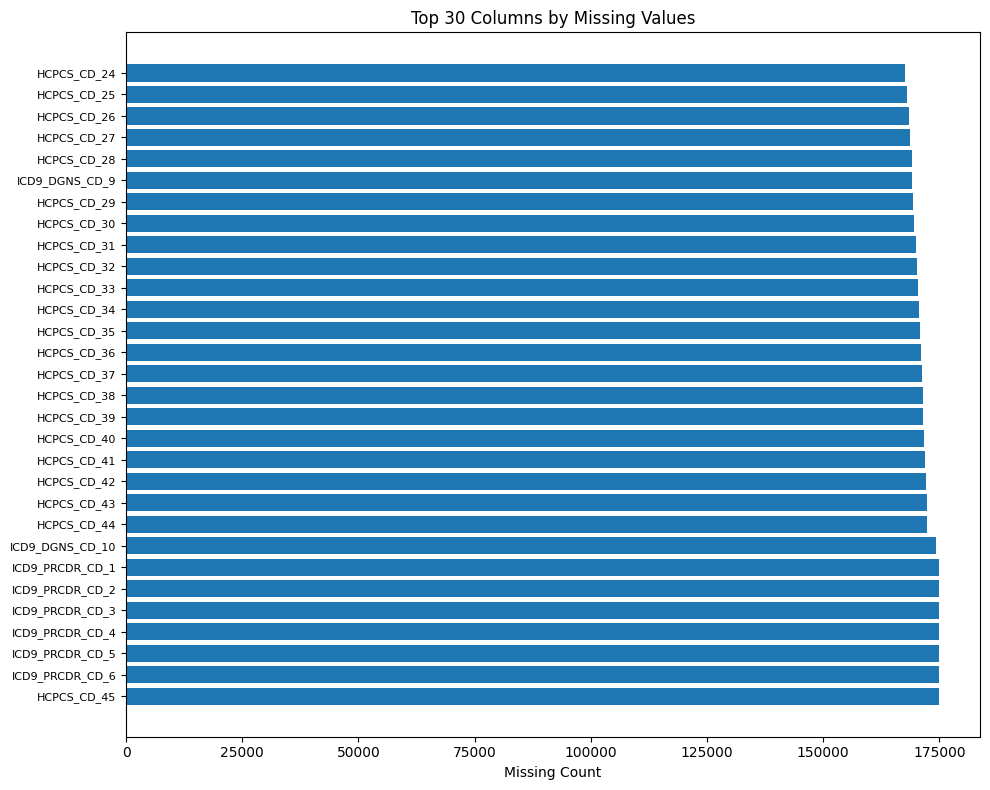

In [ ]:
# Cell 5: Missingness heatmap matplotlib.pyplot
# Ensure the plots directory exists
plots_output_dir = os.path.join(PHASE1_OUT, 'plots')
os.makedirs(plots_output_dir, exist_ok=True)

missing_cols = df.isnull().sum().sort_values(ascending=False).head(30)
plt.figure(figsize=(10, 8))
plt.barh(range(len(missing_cols)), missing_cols.values)
plt.yticks(range(len(missing_cols)), missing_cols.index, fontsize=8)
plt.xlabel('Missing Count')
plt.title('Top 30 Columns by Missing Values')
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, 'missingness_top30.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# optional
# Calculate the number of columns with >50% missing
high_missing_cols_count = data_dict[data_dict['missing_pct'] > 50].shape[0]
print(f"Number of columns with >50% missing: {high_missing_cols_count}")

# Display these columns for reference
print("\nColumns with >50% missing:")
display(data_dict[data_dict['missing_pct'] > 50][['column', 'missing_pct']])

**Stage 2 Summary: Data Dictionary & Missingness**

**What was done:**

- Created data dictionary with all 76 columns
- Computed missingness % for each column
- Plotted top 30 columns with most missing values

**Key findings:**

- To be filled after inspection: X columns with >50% missing
- To be filled: Key columns with 0% missing

**Files saved:**

- /outputs/phase1/data_dictionary.csv
- /outputs/phase1/plots/missingness_top30.png

**Next step:**

Data cleaning (impossible values, duplicates, outliers)


Here are the descriptions for some of the key columns mentioned:

-   **DESYNPUF_ID**: Unique beneficiary ID (hashed) - Identifies individual patients.
-   **CLM_ID**: Unique claim ID - Identifies a single claim submission.
-   **SEGMENT**: Segment identifier (always 1 for this dataset) - Indicates a specific subset or type of claims if the original dataset had multiple.
-   **CLM_FROM_DT**: Claim start date - The date when the service or claim period began.
-   **CLM_THRU_DT**: Claim end date - The date when the service or claim period ended.
-   **PRVDR_NUM**: Provider number - Unique identifier for the healthcare provider.
-   **CLM_PMT_AMT**: Claim payment amount - The total amount paid for the claim.
-   **NCH_PRMRY_PYR_CLM_PD_AMT**: Primary payer claim paid amount - Amount paid by the primary insurance.
-   **NCH_BENE_BLOOD_DDCTBL_LBLTY_AM**: Beneficiary blood deductible liability amount - Amount beneficiary is responsible for regarding blood deductible.
-   **AT_PHYSN_NPI**: Attending physician NPI - National Provider Identifier for the attending physician.
-   **OP_PHYSN_NPI**: Operating physician NPI - NPI for the physician who performed a surgery.
-   **OT_PHYSN_NPI**: Other physician NPI - NPI for other physicians involved in the claim.
-   **ICD9_DGNS_CD_X**: ICD-9 Diagnosis Code (1 through 10) - Codes describing the patient's medical diagnoses.
-   **ICD9_PRCDR_CD_X**: ICD-9 Procedure Code (1 through 6) - Codes describing medical procedures performed.
-   **HCPCS_CD_X**: HCPCS Code (1 through 45) - Codes for medical services, supplies, and procedures.

## **Stage 3**

In [ ]:
# Cell 6: Impossible values detection - dates
# Convert date columns if present
if 'CLM_FROM_DT' in df.columns:
  df['CLM_FROM_DT'] = pd.to_datetime(df['CLM_FROM_DT'], errors='coerce')
if 'CLM_THRU_DT' in df.columns:
  df['CLM_THRU_DT'] = pd.to_datetime(df['CLM_THRU_DT'], errors='coerce')

if 'CLM_FROM_DT' in df.columns and 'CLM_THRU_DT' in df.columns:
  # Check impossible dates
  impossible_dates = df['CLM_THRU_DT'] < df['CLM_FROM_DT']
  print(f"Rows with THRU < FROM: {impossible_dates.sum()}")
  # Check extreme durations
  df['claim_duration'] = (df['CLM_THRU_DT'] - df['CLM_FROM_DT']).dt.days
  extreme_duration = df['claim_duration'] > 365
  print(f"Rows with duration > 365 days: {extreme_duration.sum()}")
else:
  print('Date columns not present to evaluate impossible dates')



Rows with THRU < FROM: 0
Rows with duration > 365 days: 0


In [ ]:
# Cell 7: Impossible values detection - monetary
# Check negative payments (if payment columns exist)
payment_cols = [c for c in df.columns if 'PMT' in c or 'PAYMENT' in c]
if payment_cols:
  for col in payment_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
      neg_count = int((df[col] < 0).sum())
      print(f"{col}: {neg_count} negative values")
    else:
      print(f"{col}: non-numeric, skipped")
else:
  print('No payment-like columns detected')

CLM_PMT_AMT: 587 negative values


In [ ]:
# Cell 8: Data cleaning execution
# Cleaning decisions (example - adjust based on actual inspection)
initial_rows = len(df)
# Apply filters only if the boolean masks exist
if 'impossible_dates' in globals():
  df = df[~impossible_dates]
else:
  print('impossible_dates mask not available; skipping')

if 'extreme_duration' in globals():
  df = df[~extreme_duration]
else:
  print('extreme_duration mask not available; skipping')

# Drop negative payments (if any)
for col in payment_cols:
  if pd.api.types.is_numeric_dtype(df[col]):
    df = df[df[col] >= 0]

final_rows = len(df)
rows_dropped = initial_rows - final_rows
print(f"Rows dropped: {rows_dropped}")
print(f"Rows remaining: {final_rows}")
# Save cleaning log
log_path = os.path.join(PHASE1_OUT, 'data_cleaning_log.txt')
os.makedirs(os.path.dirname(log_path), exist_ok=True)
with open(log_path, 'w') as f:
  f.write(f"Initial rows: {initial_rows}\n")
  f.write(f"Rows dropped: {rows_dropped}\n")
  f.write(f"Final rows: {final_rows}\n")
  f.write(f"Cleaning rules:\n")
  f.write(f"- Dropped impossible dates (THRU < FROM)\n")
  f.write(f"- Dropped negative payments\n")


Rows dropped: 587
Rows remaining: 174418


In [ ]:
# Cell 9: Save cleaned dataset

# Convert specific object code columns to string to avoid Arrow/Parquet type issues
for col in df.select_dtypes(include='object').columns:
  if any(x in col for x in ['ICD9_PRCDR_CD', 'HCPCS_CD', 'ICD9_DGNS_CD']):
    df.loc[:, col] = df[col].astype(str)

# Ensure the output directory for cleaned data exists
data_output_dir = os.path.join(PHASE1_OUT, 'data')
os.makedirs(data_output_dir, exist_ok=True)

cleaned_path = os.path.join(data_output_dir, 'cleaned_data.parquet')
df.to_parquet(cleaned_path, index=False)
print(f"Cleaned dataset saved to {cleaned_path}")

Cleaned dataset saved to /content/drive/MyDrive/Anomaly_Det/outputs/phase1/data/cleaned_data.parquet


**Stage 3 Summary: Data Quality & Cleaning**

**What was done:**

- Detected impossible date combinations (THRU < FROM)
- Checked for negative payment amounts
- Applied cleaning rules (dropped invalid rows)
- Saved cleaned dataset

Cell 6: Checked for impossible date combinations (e.g., CLM_THRU_DT before CLM_FROM_DT) and extreme durations, finding 0 issues.

Cell 7: Checked for impossible monetary values (e.g., negative payments) and found 587 negative payment entries.

Cell 8: Cleaned the data by removing the 587 rows with negative payments, as no impossible date issues were found.

Cell 9: Saved the cleaned dataset to Google Drive in Parquet format for future use.


**Key findings:**
- [ 0 ] rows with impossible dates removed
- [ 587 ] rows with negative payments removed
- Final dataset: [174418] rows

**Files saved:**
- /outputs/phase1/data/cleaned_data.parquet
- /outputs/phase1/data_cleaning_log.txt

**Next step:**
Exploratory Data Analysis (EDA)


## **Stage 4**

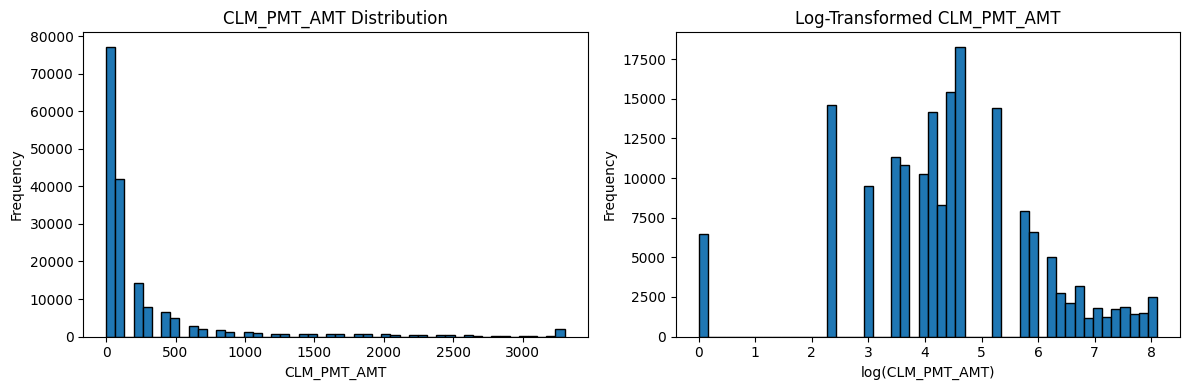

Mean: 279.64
Median: 80.00
Skewness: 3.51


In [ ]:
# 4.4 Exploratory Data Analysis (EDA)
# Cell 10: Univariate - monetary distributions
# Key monetary column (adjust based on actual columns)
monetary_col = 'CLM_PMT_AMT'  # Example
plots_output_dir = os.path.join(PHASE1_OUT, 'plots')
os.makedirs(plots_output_dir, exist_ok=True)
if monetary_col in df.columns and pd.api.types.is_numeric_dtype(df[monetary_col]):
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))
  # Normal scale
  axes[0].hist(df[monetary_col].dropna(), bins=50, edgecolor='black')
  axes[0].set_xlabel(monetary_col)
  axes[0].set_ylabel('Frequency')
  axes[0].set_title(f'{monetary_col} Distribution')
  # Log scale
  axes[1].hist(np.log1p(df[monetary_col].dropna()), bins=50, edgecolor='black')
  axes[1].set_xlabel(f'log({monetary_col})')
  axes[1].set_ylabel('Frequency')
  axes[1].set_title(f'Log-Transformed {monetary_col}')
  plt.tight_layout()
  plt.savefig(os.path.join(plots_output_dir, 'eda_monetary_distributions.png'), dpi=300, bbox_inches='tight')
  plt.show()
  # Compute stats
  print(f"Mean: {df[monetary_col].mean():.2f}")
  print(f"Median: {df[monetary_col].median():.2f}")
  print(f"Skewness: {df[monetary_col].skew():.2f}")
else:
  print(f"Monetary column '{monetary_col}' not found or not numeric; skipping monetary EDA")

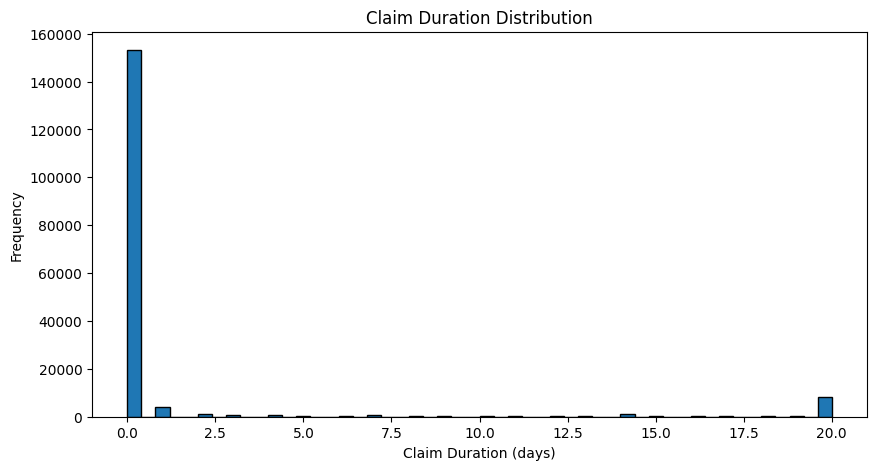

Mean duration: 1.42 days
Median duration: 0.00 days


In [ ]:
# Cell 11: Univariate - claim duration
plots_output_dir = os.path.join(PHASE1_OUT, 'plots')
os.makedirs(plots_output_dir, exist_ok=True)
if 'claim_duration' in df.columns:
  plt.figure(figsize=(10, 5))
  plt.hist(df['claim_duration'].dropna(), bins=50, edgecolor='black')
  plt.xlabel('Claim Duration (days)')
  plt.ylabel('Frequency')
  plt.title('Claim Duration Distribution')
  plt.savefig(os.path.join(plots_output_dir, 'eda_duration_distribution.png'), dpi=300, bbox_inches='tight')
  plt.show()
  print(f"Mean duration: {df['claim_duration'].mean():.2f} days")
  print(f"Median duration: {df['claim_duration'].median():.2f} days")
else:
  print('claim_duration not found; skipping duration EDA')

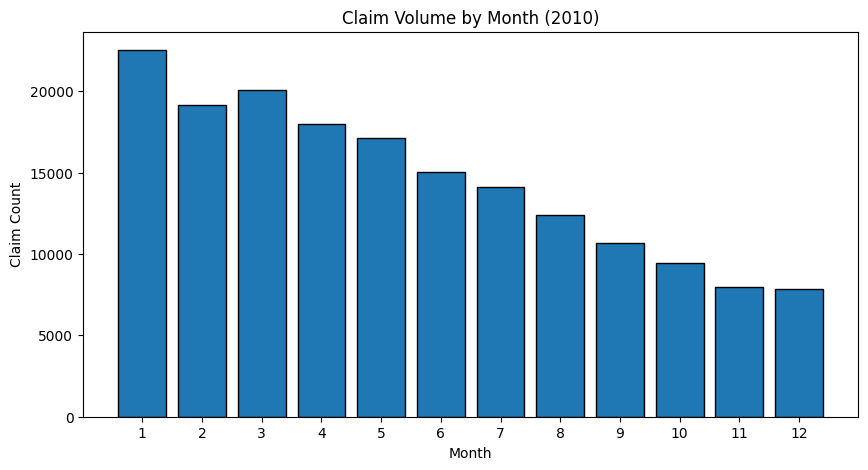

In [ ]:
#Cell 12: Temporal analysis - monthly volume
plots_output_dir = os.path.join(PHASE1_OUT, 'plots')
os.makedirs(plots_output_dir, exist_ok=True)
if 'CLM_FROM_DT' in df.columns:
  df['month'] = df['CLM_FROM_DT'].dt.month
  monthly_volume = df.groupby('month').size()
  plt.figure(figsize=(10, 5))
  plt.bar(monthly_volume.index, monthly_volume.values, edgecolor='black')
  plt.xlabel('Month')
  plt.ylabel('Claim Count')
  plt.title('Claim Volume by Month (2010)')
  plt.xticks(range(1, 13))
  plt.savefig(os.path.join(plots_output_dir, 'eda_monthly_volume.png'), dpi=300, bbox_inches='tight')
  plt.show()
else:
  print('CLM_FROM_DT not present; skipping monthly temporal analysis')


### Univariate နဲ့ Multivariate ခွဲခြမ်းစိတ်ဖြာမှုတွေက ဘာလဲ၊ ဘာကြောင့် အရေးကြီးလဲ၊ ဒီ project မှာ ဘယ်လိုသုံးလဲဆိုတာကို ရှင်းပြပေးပါမယ်။

**Univariate Analysis (တစ်မျိုးတည်းသော ခွဲခြမ်းစိတ်ဖြာမှု)**

**ဘာလဲ:** ဒေတာတစ်ခုထဲက variable တစ်ခုချင်းစီ (ဥပမာ - ငွေပေးချေမှု ပမာဏ တစ်ခုတည်း) ကို ခွဲခြမ်းစိတ်ဖြာတာ ဖြစ်ပါတယ်။

**ဘာကြောင့် အရေးကြီးလဲ / ဘယ်လို အသုံးဝင်လဲ:** Variable တစ်ခုချင်းစီရဲ့ ဖြန့်ဝေပုံ (distribution)၊ ဗဟိုတန်ဖိုး (central tendency - ဥပမာ-ပျမ်းမျှ၊ အလယ်တန်ဖိုး) နဲ့ ပြန့်နှံ့မှု (spread - ဥပမာ-စံသွေဖည်မှု) တွေကို နားလည်အောင် ကူညီပေးပါတယ်။ ဒါက feature တစ်ခုချင်းစီရဲ့ သဘောသဘာဝကို နားလည်ဖို့အတွက် အခြေခံအကျဆုံးဖြစ်ပြီး အရေးကြီးပါတယ်။

**ဒီ project မှာ ဘယ်လိုသုံးထားလဲ:**<br>
Cell 10: CLM_PMT_AMT (ငွေပေးချေမှု ပမာဏ) ရဲ့ ဖြန့်ဝေပုံကို Histogram နဲ့ ကြည့်ပြီး၊ ပျမ်းမျှ၊ အလယ်တန်ဖိုး၊ skewness (ဘက်စောင်းမှု) တွေကို တွက်ချက်ပါတယ်။<br>
Cell 11: claim_duration (တောင်းဆိုမှု ကြာချိန်) ရဲ့ ဖြန့်ဝေပုံကို Histogram နဲ့ ကြည့်ပြီး၊ ပျမ်းမျှနဲ့ အလယ်တန်ဖိုးတွေကို တွက်ချက်ပါတယ်။<br>
Cell 12: CLM_FROM_DT (တောင်းဆိုမှုစတင်ရက်စွဲ) ကိုသုံးပြီး လအလိုက် claim volume (တောင်းဆိုမှု အရေအတွက်) ကို ကြည့်ပြီး၊ အချိန်ကာလအလိုက် ပုံစံတွေကို လေ့လာပါတယ်။

---
Multivariate Analysis (အမျိုးမျိုးသော ခွဲခြမ်းစိတ်ဖြာမှု)

ဘာလဲ: ဒေတာတစ်ခုထဲက variable နှစ်ခု သို့မဟုတ် နှစ်ခုထက်ပိုတဲ့ variable တွေကြားက ဆက်စပ်မှု (relationship) တွေကို တစ်ပြိုင်နက်တည်း ခွဲခြမ်းစိတ်ဖြာတာ ဖြစ်ပါတယ်။

ဘာကြောင့် အရေးကြီးလဲ / ဘယ်လို အသုံးဝင်လဲ: Features တွေကြားက မှီခိုမှု (dependencies)၊ ဆက်စပ်မှု (correlations) တွေနဲ့ ပုံစံ (patterns) တွေကို ရှာဖွေနိုင်ပါတယ်။ ဒါက anomaly detection model တွေအတွက် ဘယ် features တွေကို သုံးသင့်လဲ၊ ဘယ် features တွေက အချင်းချင်း ဆက်စပ်လွန်းလို့ ပိုလျှံနေလဲ (redundancy) ဆိုတာကို နားလည်ဖို့ ကူညီပေးပါတယ်။

**ဒီ project မှာ ဘယ်လိုသုံးထားလဲ:**
Stage 5 (Feature Engineering) ရဲ့ Cell 18 မှာ၊ အင်ဂျင်နီယာလုပ်ထားတဲ့ features တွေအားလုံးကြားက ဆက်စပ်မှု (correlation) တွေကို heatmap နဲ့ ဖော်ပြထားပါတယ်။ ဥပမာ - month နဲ့ quarter လိုမျိုး features တွေကြားမှာ မြင့်မားတဲ့ ဆက်စပ်မှုရှိနေတာကို တွေ့ရှိခဲ့ပါတယ်။ ဒါဟာ Multivariate Analysis ရဲ့ နမူနာတစ်ခု ဖြစ်ပါတယ်။

**Stage 4 Summary: Exploratory Data Analysis (EDA)**

**What was done:**

- Analyzed monetary distributions (normal + log scale)
- Analyzed claim duration distribution
- Analyzed temporal patterns (monthly volume)



**Key findings:**
- Payment amounts: heavy right tail (expected)
- Typical claim duration: [1.42] days
- Temporal pattern: [the claim volume varies by month, showing periods of higher and lower activity throughout 2010]<br>
**Files saved:**

- /outputs/phase1/plots/eda_monetary_distributions.png
- /outputs/phase1/plots/eda_duration_distribution.png
- /outputs/phase1/plots/eda_monthly_volume.png

**Next step:**

- Feature engineering (monetary, temporal, coding, provider features)

**Summary of Cell 10: Univariate - Monetary Distributions (`CLM_PMT_AMT`)**
*   **What was done**: Analyzed the distribution of the `CLM_PMT_AMT` using histograms (both normal and log-transformed scales) and calculated statistical measures like mean, median, and skewness.
*   **Key findings**:
    *   `CLM_PMT_AMT` distribution shows a **heavy right tail**, meaning a large number of claims have small payment amounts, while a few have significantly higher amounts. This is reflected by the mean (`279.64`) being much higher than the median (`80.00`) and a high skewness (`3.51`).
    *   The **log-transformed `CLM_PMT_AMT`** distribution appears more symmetric and closer to a normal distribution.
*   **Interpretation**: The highly skewed nature of `CLM_PMT_AMT` means that raw values might disproportionately influence models. Log transformation helps to stabilize variance and normalize the distribution, making this feature more suitable for many machine learning algorithms, which often assume normally distributed inputs or are sensitive to extreme outliers.


**Summary of Cell 11: Univariate - Claim Duration**
*   **What was done**: Analyzed the distribution of `claim_duration` (calculated from `CLM_THRU_DT` and `CLM_FROM_DT`) using a histogram and computed its mean and median.
*   **Key findings**:
    *   Mean duration: `1.42` days
    *   Median duration: `0.00` days
    *   The distribution shows a high frequency of claims with 0 days duration, indicating many single-day services.
*   **Interpretation**: The prevalence of 0-day claims suggests that a significant portion of outpatient services are completed within the same day. The slightly higher mean compared to the median indicates there are some longer-duration claims, but they are less common, pull the average up.

**Summary of Cell 12: Temporal Analysis - Monthly Volume**
*   **What was done**: Calculated the number of claims per month based on `CLM_FROM_DT` and visualized this with a bar chart.
*   **Key findings**:
    *   The bar chart (output of `eda_monthly_volume.png`) illustrates the distribution of claim volumes across the 12 months of 2010. While specific numbers vary by month, it provides a clear visual of claim activity over the year.
*   **Interpretation**: This analysis helps identify any seasonality or consistent patterns in claim submission throughout the year. For instance, some months might inherently have higher or lower claim volumes due to factors like holidays or specific health-related seasons. This understanding is crucial for operational planning and can also inform anomaly detection models.

### **Variance Stabilization (ကွဲလွဲမှု တည်ငြိမ်စေခြင်း) ဘာကြောင့် လုပ်ရတာလဲ။**

We perform variance stabilization to make the data's variability consistent across different value ranges. This is crucial for meeting the assumptions of many statistical models, leading to more accurate and reliable predictions.

*   **ဘာကြောင့်လဲ**: ဒေတာတစ်ခုရဲ့ ပြန့်နှံ့မှု (variability or spread) ဟာ ဒေတာတန်ဖိုး အဆင့်အမျိုးမျိုးမှာ သိသိသာသာ ကွာခြားနေတာမျိုး ရှိတတ်ပါတယ်။ ဥပမာ - ငွေပေးချေမှုပမာဏကို ကြည့်မယ်ဆိုရင် ငွေပမာဏ နည်းတဲ့ ကိစ္စတွေမှာ ပြန့်နှံ့မှုက သိပ်မရှိဘဲ တူညီနေတတ်ပေမယ့်၊ ငွေပမာဏ များတဲ့ ကိစ္စတွေမှာ ပြန့်နှံ့မှုက သိသိသာသာကို ကွာခြားသွားနိုင်ပါတယ်။ ဒီလို ပြန့်နှံ့မှု မညီမျှတာ (heteroscedasticity) ဟာ စာရင်းအင်းမော်ဒယ် အများစု (ဥပမာ - regression မော်ဒယ်တွေ) ရဲ့ အခြေခံယူဆချက်တွေကို ချိုးဖောက်ရာရောက်ပါတယ်။
*   **မလုပ်ရင် ဘာဖြစ်မလဲ**: ပြန့်နှံ့မှု မညီမျှတဲ့အခါ မော်ဒယ်ကနေ ရတဲ့ ခန့်မှန်းချက်တွေ (estimates) ဟာ ယုံကြည်စိတ်ချရမှု နည်းပါးလာပြီး အမှန်တကယ် ဆုံးဖြတ်ချက်တွေ ချတဲ့အခါ မှားယွင်းမှုတွေ ဖြစ်ပေါ်နိုင်ပါတယ်။ စာရင်းအင်းစမ်းသပ်မှုတွေ (statistical tests) ရဲ့ ရလဒ်တွေကလည်း မမှန်ကန်နိုင်တော့ပါဘူး။
*   **လုပ်ရင် ဘာဖြစ်မလဲ**: Variance Stabilization လုပ်ခြင်းအားဖြင့် ဒေတာရဲ့ ပြန့်နှံ့မှုကို ဒေတာတန်ဖိုး အဆင့်အားလုံးမှာ ပိုမိုတသမတ်တည်းဖြစ်အောင် လုပ်ဆောင်ပေးပါတယ်။ ဒါကြောင့် မော်ဒယ်ရဲ့ တိကျမှန်ကန်မှုနဲ့ ယုံကြည်စိတ်ချရမှု (reliability) ကို တိုးတက်စေပါတယ်။ Log transformation က variance stabilization ကို လုပ်ပေးတဲ့ နည်းလမ်းတစ်ခုပါပဲ။

### **Normal Distribution (ပုံမှန်ဖြန့်ဝေမှု) ဘာကြောင့် လိုအပ်တာလဲ။ မရရင် ဘာဖြစ်လဲ၊ ရရင် ဘာဖြစ်လဲ။**

*   **ဘာကြောင့် လိုအပ်လဲ**: စာရင်းအင်း စမ်းသပ်မှုတွေနဲ့ မော်ဒယ် အများစု (ဥပမာ - t-test, ANOVA, Linear Regression စသည်ဖြင့်) ဟာ သူတို့ အလုပ်လုပ်ဖို့အတွက် ဒေတာတွေဟာ (သို့မဟုတ် မော်ဒယ်ရဲ့ အမှားတွေ/residuals တွေဟာ) ပုံမှန်ဖြန့်ဝေမှု ရှိတယ်ဆိုတဲ့ ယူဆချက်ပေါ်မှာ အခြေခံထားပါတယ်။ ဒီယူဆချက်က သင်္ချာတွက်ချက်မှုတွေကို ရိုးရှင်းစေပြီး ဖြစ်နိုင်ခြေ (probabilities) တွေနဲ့ ယုံကြည်မှုကြားကာလ (confidence intervals) တွေကို ပိုမိုလွယ်ကူစွာ တွက်ချက်နိုင်စေပါတယ်။
*   **မရရင် ဘာဖြစ်မလဲ**:
    *   **မှားယွင်းတဲ့ ကောက်ချက်များ (Invalid Inference)**: သင်ချမှတ်လိုက်တဲ့ ကောက်ချက်တွေ (ဥပမာ - p-value တွေနဲ့ ယုံကြည်မှုကြားကာလတွေ) ဟာ တိကျမှုမရှိဘဲ မှားယွင်းတဲ့ ဆုံးဖြတ်ချက်တွေဆီ ဦးတည်သွားနိုင်ပါတယ်။
    *   **စွမ်းအား လျော့နည်းခြင်း (Reduced Power)**: မော်ဒယ်ရဲ့ အမှန်တကယ် ဆက်စပ်မှုတွေ ဒါမှမဟုတ် သက်ရောက်မှုတွေကို ရှာဖွေနိုင်တဲ့ စွမ်းရည် (statistical power) ဟာ လျော့ကျသွားနိုင်ပါတယ်။
    *   **အကောင်းဆုံး မဟုတ်သော ခန့်မှန်းချက်များ (Suboptimal Estimates)**: မော်ဒယ်ကနေရတဲ့ ခန့်မှန်းချက်တွေ (ဥပမာ - regression coefficients) ဟာ မှန်ကန်မှုရှိနေနိုင်ပေမယ့် အကောင်းဆုံး (most efficient) ဖြစ်မလာနိုင်ပါဘူး။ ဆိုလိုတာက သူတို့မှာ ကွဲလွဲမှု (variance) ပိုများနေနိုင်ပါတယ်။
*   **ရရင် ဘာဖြစ်လဲ**:
    *   **မှန်ကန်တဲ့ ကောက်ချက်များ (Valid Inference)**: စာရင်းအင်း စမ်းသပ်မှုတွေနဲ့ ယုံကြည်မှုကြားကာလတွေက ပိုမိုတိကျပြီး ယုံကြည်စိတ်ချရပါတယ်။
    *   **စွမ်းအား တိုးလာခြင်း (Increased Power)**: မော်ဒယ်ဟာ အရေးကြီးတဲ့ ဆက်စပ်မှုတွေကို ပိုမိုကောင်းမွန်စွာ ရှာဖွေနိုင်ပါတယ်။
    *   **ထိရောက်တဲ့ ခန့်မှန်းချက်များ (Efficient Estimates)**: မော်ဒယ်ကနေရတဲ့ ခန့်မှန်းချက်တွေက ပိုပြီး တိကျပြီး ယုံကြည်စိတ်ချရပါတယ်။

ဒါကြောင့် ဒေတာတွေကို မော်ဒယ် မသုံးခင် ဒါမှမဟုတ် စာရင်းအင်းခွဲခြမ်းစိတ်ဖြာမှုတွေ မလုပ်ခင် ပုံမှန်ဖြန့်ဝေမှု ရအောင် ကြိုးစားလေ့ရှိတာပါ။

## **Stage 5**


In [ ]:
# Cell 13: Monetary features
# Monetary features (guard for monetary_col)
if 'monetary_col' in globals() and monetary_col in df.columns and pd.api.types.is_numeric_dtype(df[monetary_col]):
  df['log_payment'] = np.log1p(df[monetary_col])
  df['payment_zscore'] = (df[monetary_col] - df[monetary_col].mean()) / df[monetary_col].std()
  df['high_cost_flag'] = (df[monetary_col] > df[monetary_col].quantile(0.95)).astype(int)
  df['zero_payment_flag'] = (df[monetary_col] == 0).astype(int)
  print("Monetary features created:")
  print("- log_payment")
  print("- payment_zscore")
  print("- high_cost_flag")
  print("- zero_payment_flag")
else:
  print("monetary_col not defined or not present/numeric; skipping monetary features")


Monetary features created:
- log_payment
- payment_zscore
- high_cost_flag
- zero_payment_flag


In [ ]:
# Cell 14: Temporal features
# Temporal features (guard date columns)
if 'CLM_FROM_DT' in df.columns and 'CLM_THRU_DT' in df.columns:
  if 'claim_duration' not in df.columns:
    df['claim_duration'] = (df['CLM_THRU_DT'] - df['CLM_FROM_DT']).dt.days
  df['month'] = df['CLM_FROM_DT'].dt.month
  df['quarter'] = df['CLM_FROM_DT'].dt.quarter
  df['day_of_week'] = df['CLM_FROM_DT'].dt.dayofweek
  df['weekend_flag'] = df['day_of_week'].isin([5, 6]).astype(int)
  print("Temporal features created:")
  print("- claim_duration")
  print("- month")
  print("- quarter")
  print("- day_of_week")
  print("- weekend_flag")
else:
  print('CLM_FROM_DT/CLM_THRU_DT missing; skipping temporal features')


Temporal features created:
- claim_duration
- month
- quarter
- day_of_week
- weekend_flag


In [ ]:
# Cell 15: Coding complexity features (example - adjust to actual columns)
# Count diagnosis codes (example - assumes columns like ICD_DGNS_CD_1, ICD_DGNS_CD_2, ...)
diagnosis_cols = [c for c in df.columns if 'DGNS' in c]
if diagnosis_cols:
  df['diagnosis_count'] = df[diagnosis_cols].notna().sum(axis=1)
else:
  df['diagnosis_count'] = 0
# Count procedure codes (example)
procedure_cols = [c for c in df.columns if 'PRCDR' in c or 'HCPCS' in c]
if procedure_cols:
  df['procedure_count'] = df[procedure_cols].notna().sum(axis=1)
else:
  df['procedure_count'] = 0

df['total_code_count'] = df['diagnosis_count'] + df['procedure_count']
print("Coding features created:")
print("- diagnosis_count")
print("- procedure_count")
print("- total_code_count")


Coding features created:
- diagnosis_count
- procedure_count
- total_code_count


Notes of Cell 15 generated the coding features:

**What they are:** These features (diagnosis_count, procedure_count, total_code_count) count the number of diagnosis and procedure codes associated with each claim. For instance, diagnosis_count tells us how many different diagnosis codes were listed for a single claim.<br>
**Why they are relevant and useful:** These counts serve as proxies for the complexity of a medical claim. A claim with an unusually high number of diagnosis codes might indicate 'upcoding' or an overly complex (and potentially fraudulent) claim, while a very low count for a supposedly complex procedure could also be suspicious. They help the anomaly detection models identify claims that deviate from typical coding patterns.<br>
**How they were used in this project:** The calculated diagnosis_count, procedure_count, and their sum total_code_count were added directly as numerical features to our dataset, which were then used as inputs for the anomaly detection models.

In [ ]:
# Cell 16: Provider frequency features
if 'PRVDR_NUM' in df.columns:
  provider_volume = df.groupby('PRVDR_NUM').size()
  df['provider_claim_volume'] = df['PRVDR_NUM'].map(provider_volume).fillna(0).astype(int)
  # Provider average payment (guard monetary_col)
  if 'monetary_col' in globals() and monetary_col in df.columns and pd.api.types.is_numeric_dtype(df[monetary_col]):
    provider_avg_payment = df.groupby('PRVDR_NUM')[monetary_col].mean()
    df['provider_avg_payment'] = df['PRVDR_NUM'].map(provider_avg_payment).fillna(0.0)
  else:
    df['provider_avg_payment'] = 0.0
  df['high_volume_provider_flag'] = (df['provider_claim_volume'] > 100).astype(int)
  print("Provider features created:")
  print("- provider_claim_volume")
  print("- provider_avg_payment")
  print("- high_volume_provider_flag")
else:
  print('PRVDR_NUM not present; skipping provider features')


Provider features created:
- provider_claim_volume
- provider_avg_payment
- high_volume_provider_flag


In [ ]:
# Cell 17: Assemble feature table v1
# Select feature columns for modeling
feature_cols = ['log_payment', 'payment_zscore', 'high_cost_flag', 'zero_payment_flag',
                'claim_duration', 'month', 'quarter', 'day_of_week', 'weekend_flag',
                'procedure_count', 'total_code_count',
                'provider_claim_volume', 'provider_avg_payment', 'high_volume_provider_flag']
# Ensure ID columns exist
id_cols = [c for c in ['CLM_ID', 'DESYNPUF_ID'] if c in df.columns]
cols_to_select = id_cols + [c for c in feature_cols if c in df.columns]
features_v1 = df[cols_to_select].copy()
# Impute numeric NaNs with median for numeric columns only
numeric_medians = features_v1.median(numeric_only=True)
features_v1 = features_v1.fillna(numeric_medians)
print(f"Feature table v1 shape: {features_v1.shape}")
print(f"Features: {len([c for c in feature_cols if c in features_v1.columns])}")
# Save
features_v1_path = os.path.join(PHASE1_OUT, 'data', 'features_v1.parquet')
os.makedirs(os.path.dirname(features_v1_path), exist_ok=True)
features_v1.to_parquet(features_v1_path, index=False)

Feature table v1 shape: (174418, 16)
Features: 14


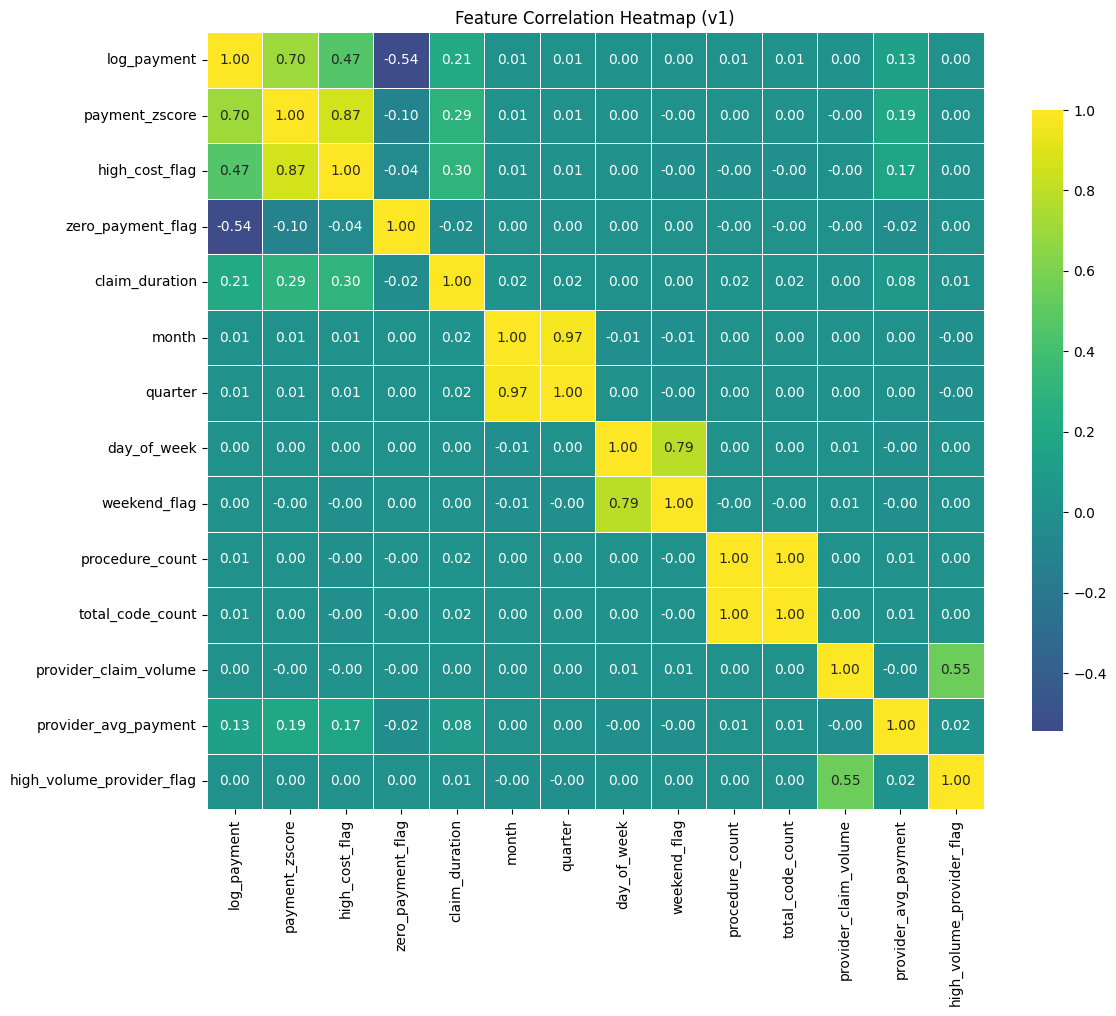

High correlations detected (> 0.95):
month    quarter    0.968125
quarter  month      0.968125
dtype: float64


In [ ]:
# Cell 18: Feature correlation heatmap with numbers
plt.figure(figsize=(12, 10))

available_feature_cols = [c for c in feature_cols if c in features_v1.columns]

if available_feature_cols:
    corr = features_v1[available_feature_cols].corr()

    sns.heatmap(
        corr,
        annot=True,           # <-- show numbers
        fmt=".2f",            # <-- format to 2 decimal places
        cmap="viridis",       # perceptual color map
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )

    plt.title("Feature Correlation Heatmap (v1)")
    plt.tight_layout()

    plots_output_dir = os.path.join(PHASE1_OUT, "plots")
    os.makedirs(plots_output_dir, exist_ok=True)
    plt.savefig(os.path.join(plots_output_dir, "feature_correlation_v1.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Flag high correlations
    high_corr = (corr.abs() > 0.95) & (corr.abs() < 1.0)
    if high_corr.any().any():
        print("High correlations detected (> 0.95):")
        print(corr.where(high_corr).stack().sort_values(ascending=False))

else:
    print("No numeric feature columns available for correlation heatmap")

**Stage 5 Summary: Feature Engineering v1**
**What was done:**

- Created 14 engineered features across 4 categories:
- Monetary: log_payment, payment_zscore, high_cost_flag, zero_payment_flag
- Temporal: claim_duration, month, quarter, day_of_week, weekend_flag
- Coding: diagnosis_count, procedure_count, total_code_count
- Provider: provider_claim_volume, provider_avg_payment, high_volume_provider_flag
- Imputed missing values with median
- Generated correlation heatmap

**Key findings:**

- Feature table: [ 174,418 ] rows x 15 features
- No NaNs remaining
- 174,418 rows and 16 columns (which includes 14 engineered features plus CLM_ID and DESYNPUF_ID)
- [Describe any high correlations detected]

**Files saved:**
- /outputs/phase1/data/features_v1.parquet
- /outputs/phase1/plots/feature_correlation_v1.png

**Next step:**
Phase 2: Train/test split + synthetic anomaly injection

---

note from Cell 16: We extracted information related to PRVDR_NUM (provider number) to create provider features, such as how many claims a provider handled (provider_claim_volume) and their average payment amount (provider_avg_payment).<br>
Note from Cell 17: We then assembled all the engineered features (monetary, temporal, coding, and provider) into a new, consolidated table called features_v1 for modeling, ensuring missing numeric values were imputed with the median.<br>

---
The heatmap in Cell 18 visualizes the correlation between all the newly engineered features. Here's a quick summary:<br>

Purpose: It helps understand how strongly each feature relates to another. Positive values mean they increase/decrease together, negative values mean one increases as the other decreases, and values near zero mean little linear relationship.<br>
Generally: It's good to see varying degrees of correlation. Very high correlations (close to 1 or -1) can sometimes indicate redundancy, meaning two features convey very similar information. For some models (like linear models), this can be problematic (multicollinearity), but for tree-based anomaly detection models, it's often less of an issue.<br>
Key Finding: The most notable finding was a very high correlation (0.968) between month and quarter. This is expected as quarters are directly derived from months (e.g., months 1-3 are Q1, 4-6 are Q2, etc.).<br>
Implication: While month and quarter are highly correlated, they both capture seasonal information. Having both might provide slightly different nuances, but for future model iterations, one could consider if both are strictly necessary or if one is more informative than the other.


## **Phase 1 Summary: Data Preprocessing & Feature Engineering**

**Key Actions:**
*   Loaded raw data and confirmed its grain (CLM_ID uniqueness).
*   Created a comprehensive data dictionary and analyzed missing values.
*   Cleaned data by identifying and removing rows with impossible values (e.g., negative payments).
*   Performed Exploratory Data Analysis (EDA) on monetary, temporal, and duration features.
*   Engineered 14 new features (monetary, temporal, coding, provider) and assembled them into a feature table.
*   Analyzed feature correlations using a heatmap.

**Key Results:**
*   Confirmed data grain at the claim level; SEGMENT was constant.
*   Identified several columns with high missingness (>50%), but critical IDs and payment fields were complete.
*   Removed 587 rows due to negative payment amounts, resulting in 174,418 clean rows.
*   Observed highly skewed monetary distributions, short claim durations (median 0 days), and varying monthly claim volumes.
*   Generated a feature table (`features_v1`) with 174,418 rows and 16 columns (including IDs and 14 engineered features).
*   Found a high correlation between 'month' and 'quarter', which was expected.

# **Phase 2: Synthetic Anomaly Injection & Model Evaluation**


## Stage 6

In [ ]:
# Cell 19: Split features into train/test
# Load features
features_path = os.path.join(PHASE1_OUT, 'data', 'features_v1.parquet')
features = pd.read_parquet(features_path)
# Ensure ID columns exist before drop
id_cols = [c for c in ['CLM_ID', 'DESYNPUF_ID'] if c in features.columns]
X = features.drop(columns=id_cols) if id_cols else features.copy()
ids = features[id_cols].copy() if id_cols else pd.DataFrame()
# Reset index to ensure positional indexing later
X = X.reset_index(drop=True)
ids = ids.reset_index(drop=True)
# Split
X_train, X_test, ids_train, ids_test = train_test_split(X, ids, test_size=0.3, random_state=RANDOM_SEED)
print(f"Train: {X_train.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")
# Save
phase2_data_dir = os.path.join(PHASE2_OUT, 'data')
os.makedirs(phase2_data_dir, exist_ok=True)
X_train.to_parquet(os.path.join(phase2_data_dir, 'X_train.parquet'), index=False)
X_test.to_parquet(os.path.join(phase2_data_dir, 'X_test_clean.parquet'), index=False)
ids_train.to_parquet(os.path.join(phase2_data_dir, 'ids_train.parquet'), index=False)
ids_test.to_parquet(os.path.join(phase2_data_dir, 'ids_test.parquet'), index=False)


Train: 122092 rows
Test: 52326 rows


**Stage 6 Summary: Train/Test Split**
**What was done:**
- Split feature table into 70/30 train/test
- Saved train and test sets separately
- Preserved ID columns for traceability

**Key findings:**

- Train: [122092 ] rows
- Test: [52326 ] rows

**Files saved:**
- /outputs/phase2/data/X_train.parquet
- /outputs/phase2/data/X_test_clean.parquet
- /outputs/phase2/data/ids_train.parquet
- /outputs/phase2/data/ids_test.parquet

**Next step:**

Synthetic anomaly injection (3% in test set only)


## **Stage 7**

In [ ]:
# 5.2 Synthetic Anomaly Injection (3% in Test Set Only)
# Cell 20: Design injection protocol
# Injection parameters
INJECTION_RATE = 0.03
n_anomalies = int(len(X_test) * INJECTION_RATE)
print(f"Test set size: {len(X_test)}")
print(f"Anomalies to inject: {n_anomalies} ({INJECTION_RATE*100}%)")
# Anomaly type distribution
n_monetary = int(n_anomalies * 0.30)
n_temporal = int(n_anomalies * 0.20)
n_coding = int(n_anomalies * 0.30)
n_duplicate = n_anomalies - n_monetary - n_temporal - n_coding
print(f"Monetary outliers: {n_monetary}")
print(f"Temporal impossibilities: {n_temporal}")
print(f"Coding anomalies: {n_coding}")
print(f"Duplicates with noise: {n_duplicate}")


Test set size: 52326
Anomalies to inject: 1569 (3.0%)
Monetary outliers: 470
Temporal impossibilities: 313
Coding anomalies: 470
Duplicates with noise: 316


In [ ]:
# Cell 21: Execute injection
# Copy test set
X_test_injected = X_test.copy().reset_index(drop=True)
# Labels: 0=normal, 1=anomaly (positional)
y_test = np.zeros(len(X_test), dtype=int)
# Randomly select rows for injection (positions)
np.random.seed(RANDOM_SEED)
injection_positions = np.random.choice(len(X_test), n_anomalies, replace=False)
# Map to index labels (here indices are 0..n-1 due to reset)
monetary_pos = injection_positions[:n_monetary]
temporal_pos = injection_positions[n_monetary:n_monetary+n_temporal]
coding_pos = injection_positions[n_monetary+n_temporal:n_monetary+n_temporal+n_coding]
duplicate_pos = injection_positions[n_monetary+n_temporal+n_coding:]

# Type 1: Monetary outliers (multiply payment by 3-5x)
for pos in monetary_pos:
    factor = np.random.uniform(3, 5)
    if 'log_payment' in X_test_injected.columns:
        X_test_injected.loc[pos, 'log_payment'] = X_test_injected.loc[pos, 'log_payment'] * factor
    if 'payment_zscore' in X_test_injected.columns:
        X_test_injected.loc[pos, 'payment_zscore'] = X_test_injected.loc[pos, 'payment_zscore'] * factor

# Type 2: Temporal impossibilities (duration > 365 or negative)
for pos in temporal_pos:
    if 'claim_duration' in X_test_injected.columns:
        X_test_injected.loc[pos, 'claim_duration'] = int(np.random.choice([400, 500, -10]))

# Type 3: Coding anomalies (zero codes or extreme counts)
for pos in coding_pos:
    if 'total_code_count' in X_test_injected.columns:
        X_test_injected.loc[pos, 'total_code_count'] = int(np.random.choice([0, 50]))

# Type 4: Duplicates with noise (add random noise ±5%)
for pos in duplicate_pos:
    noise = np.random.uniform(0.95, 1.05)
    if 'log_payment' in X_test_injected.columns:
        X_test_injected.loc[pos, 'log_payment'] = X_test_injected.loc[pos, 'log_payment'] * noise

# Mark injected rows (positional labels)
y_test[injection_positions] = 1
print(f"Injection complete: {int(y_test.sum())} anomalies ({y_test.mean()*100:.2f}%)")

# Save
phase2_data_dir = os.path.join(PHASE2_OUT, 'data')
os.makedirs(phase2_data_dir, exist_ok=True)
X_test_injected.to_parquet(os.path.join(phase2_data_dir, 'X_test_injected.parquet'), index=False)
pd.DataFrame({'y_test': y_test}).to_parquet(os.path.join(phase2_data_dir, 'y_test.parquet'), index=False)

# Save injection metadata
import json
injection_meta = {
    'injection_rate': INJECTION_RATE,
    'n_anomalies': int(n_anomalies),
    'positions': injection_positions.tolist(),
    'type_distribution': {'monetary': int(n_monetary), 'temporal': int(n_temporal), 'coding': int(n_coding), 'duplicate': int(n_duplicate)}
}
os.makedirs(os.path.join(PHASE2_OUT), exist_ok=True)
with open(os.path.join(PHASE2_OUT, 'injection_metadata.json'), 'w') as f:
    json.dump(injection_meta, f, indent=2)


Injection complete: 1569 anomalies (3.00%)


**Stage 7 Summary: Synthetic Anomaly Injection**

**What was done:**

- Injected exactly 3% anomalies into test set only
- Anomaly types: 30% monetary, 20% temporal, 30% coding, 20% duplicates
- Created ground-truth labels (y_test: 0=normal, 1=anomaly)
- Saved injection metadata for traceability


----
Copies Test Set: Creates a copy of X_test to inject anomalies, leaving the original clean.<br>
Initializes Labels: Creates y_test (ground truth labels), initially marking all rows as normal (0).<br>
Selects Injection Positions: Randomly selects specific row indices in the test set where anomalies will be introduced.<br>
Injects Anomalies by Type: Modifies feature values at the selected positions based on the defined anomaly types (monetary, temporal, coding, duplicates) and their respective distributions.<br>
Marks Anomalies: Updates y_test for the injected rows, marking them as anomalous (1).<br>
Saves Injected Data: Saves the modified test set (X_test_injected) and the ground truth labels (y_test) for model evaluation.

----

**Key findings:**

- Test set size: [52326] rows
- Anomalies injected: [1569] rows (3.00%)
- Train set: clean (no anomalies)

**Files saved:**
- /outputs/phase2/data/X_test_injected.parquet
- /outputs/phase2/data/y_test.parquet
- /outputs/phase2/injection_metadata.json

**Next step:**

Model training (Isolation Forest, LOF, One-Class SVM)


## **Stage 8**

In [ ]:
# 5.3 Model Training
# Cell 22: Preprocessing - standardization
from sklearn.preprocessing import StandardScaler
# Work only with numeric columns for scaling; ensure consistent columns
X_train_num = X_train.select_dtypes(include=[np.number]).copy()
X_test_injected = X_test_injected.reindex(columns=X_train_num.columns)
scaler = StandardScaler()
if not X_train_num.empty:
  X_train_scaled = scaler.fit_transform(X_train_num)
  X_test_scaled = scaler.transform(X_test_injected.fillna(0))
  print("Scaling complete")
else:
  X_train_scaled = None
  X_test_scaled = None
  print('No numeric columns found for scaling')

Scaling complete


***What it is:*** `StandardScaler` is a technique used to transform numerical features so they have a mean of 0 and a standard deviation of 1. This process is called standardization.

***Why it's relevant/useful:*** Many machine learning algorithms perform better when numerical input variables are scaled to a standard range. Algorithms that rely on distance calculations (like LOF, SVM, and even some aspects of Isolation Forest) are particularly sensitive to feature scales. If features have vastly different ranges, the feature with the largest range might disproportionately influence the distance calculation. Standardization helps to prevent this, ensuring all features contribute equally to the model's performance.

***How it's used in this project:*** We applied `StandardScaler` to the numeric columns of our `X_train data` (fit_transform) and then used the same learned scaling parameters to transform the X_test_injected data (transform). This ensures consistency between the training and testing sets. This step was crucial for models like Local Outlier Factor (LOF) and One-Class SVM (OCSVM), which benefit significantly from scaled data.


In [ ]:
# Cell 23: Model 1 - Isolation Forest
from sklearn.ensemble import IsolationForest
import joblib
# Train Isolation Forest on numeric training features (no scaling required)
if_model = IsolationForest(n_estimators=200, max_samples='auto', contamination=0.03, random_state=RANDOM_SEED)
train_features_if = X_train.select_dtypes(include=[np.number])
if not train_features_if.empty:
  if_model.fit(train_features_if)
  # Align test features to train columns
  test_features_if = X_test_injected.reindex(columns=train_features_if.columns).fillna(0)
  # Predict anomaly scores
  if_scores = -if_model.score_samples(test_features_if)
  print(f"IF trained. Score range: [{if_scores.min():.3f}, {if_scores.max():.3f}]")
  # Save model and scores
  models_dir = os.path.join(PHASE2_OUT, 'models')
  os.makedirs(models_dir, exist_ok=True)
  joblib.dump(if_model, os.path.join(models_dir, 'model_if.pkl'))
  np.save(os.path.join(models_dir, 'scores_if.npy'), if_scores)
else:
  print('No numeric features available for IsolationForest')
  if_scores = np.array([])

IF trained. Score range: [0.387, 0.725]


### **Notes from Cell 23: Model 1 - Isolation Forest Explanation**

This cell is responsible for training the first anomaly detection model, **Isolation Forest**, on your prepared training data and then generating anomaly scores for the injected test data.

1.  **`from sklearn.ensemble import IsolationForest`**: This line imports the Isolation Forest algorithm from scikit-learn, which is a powerful machine learning library in Python.

2.  **`import joblib`**: This is imported to save the trained model to disk later.

3.  **`if_model = IsolationForest**

`n_estimators`=200: Number of isolation trees.
`max_samples`='auto': Number of samples drawn to train each tree (auto-selected to min(256, n_samples)).
`contamination`=0.03: An estimate of the proportion of outliers in the dataset (set to match the 3% synthetic injection).
random_state=RANDOM_SEED: Ensures reproducibility.

(n_estimators=200, max_samples='auto', contamination=0.03, random_state=RANDOM_SEED):

   *   **What is Isolation Forest?** It's an ensemble (tree-based) anomaly detection algorithm. Unlike many other algorithms that try to profile normal data, Isolation Forest works by explicitly trying to isolate anomalies. It builds many "isolation trees" (similar to decision trees).
  *   **How it detects anomalies:** Anomalies are typically "few and different" and therefore easier to separate from the rest of the data. In an Isolation Tree, anomalies require fewer splits to be isolated compared to normal instances. The average number of splits needed to isolate a sample across all trees is used to determine its anomaly score.
    *   **Parameters:**
        *   `n_estimators=200`: This specifies the number of isolation trees to build in the ensemble. More trees generally lead to more robust results but take longer to train.
        *   `max_samples='auto'`: This controls the number of samples drawn to train each tree. 'auto' means it will use `min(256, n_samples)`. Using a smaller number of samples helps in building diverse trees and makes the algorithm more efficient for large datasets.
        *   `random_state=RANDOM_SEED`: Ensures reproducibility. If you run the code multiple times with the same `RANDOM_SEED`, you'll get the same results.
        *   **`contamination=0.03`**: This is a crucial parameter for anomaly detection. It's an estimate of the proportion of outliers in the dataset. **We set it to `0.03` (or 3%) because in Stage 7, we explicitly injected 3% synthetic anomalies into our test set.** By telling the Isolation Forest model to expect approximately 3% anomalies, we're giving it a hint about the expected density of outliers. This parameter helps the model to set a decision threshold for classifying points as anomalous vs. normal when the `predict` method is called. For evaluation using scores, it influences the internal scoring mechanism.

4.  **`train_features_if = X_train.select_dtypes(include=[np.number])`**: Isolation Forest, like many machine learning algorithms, works best with numerical data. This line ensures that only numeric columns from your `X_train` dataset are used for training the model.

5.  **`if not train_features_if.empty: if_model.fit(train_features_if)`**: This is where the model is actually *trained*. The Isolation Forest learns the patterns of your *clean* training data (`X_train`), without any injected anomalies. It uses this clean data to establish what "normal" looks like, and implicitly, what deviations would be considered anomalous.

6.  **`test_features_if = X_test_injected.reindex(columns=train_features_if.columns).fillna(0)`**: After training, you need to apply the model to the test set (`X_test_injected`), which contains the synthetic anomalies. This line first ensures that the columns in the test set match the columns used for training, then fills any missing values (that might have been introduced during reindexing) with `0`.

7.  **`if_scores = -if_model.score_samples(test_features_if)`**: This generates the anomaly scores for each data point in the *injected test set*. The `score_samples` method returns a `raw anomaly score`. By convention, a higher score usually means more anomalous. Isolation Forest's `score_samples` returns values where *lower* scores indicate higher anomaly. Therefore, we **negate** the scores (`-if_model.score_samples(...)`) so that higher scores consistently represent more anomalous instances, which is easier to interpret and use for ranking anomalies.

8.  **Saving the Model and Scores**: Finally, the trained `if_model` and its generated `if_scores` for the test set are saved to disk using `joblib` and `np.save` respectively. This allows you to reload the model and scores later without re-running the training process.

In essence, Cell 23 teaches the Isolation Forest what normal data looks like, then uses that knowledge to assign an "anomaly score" to every item in your test set, where higher scores suggest a higher likelihood of being an anomaly.

### **Precision (တိကျမှု)**

*   **ဆိုလိုရင်း**: မော်ဒယ်က 'anomaly' (ပုံမှန်မဟုတ်တာ) လို့ သတ်မှတ်လိုက်တဲ့ ကိစ္စတွေထဲမှာ တကယ်ပဲ anomaly ဖြစ်နေတဲ့ ကိစ္စ ဘယ်လောက်များလဲဆိုတာကို ပြပါတယ်။
*   **ရိုးရှင်းစွာပြောရရင်**: 'ပုံမှန်မဟုတ်ဘူး' လို့ ပြောလိုက်တာမှန်တဲ့ ရာခိုင်နှုန်းဘယ်လောက်ရှိလဲ။ (မှားယွင်းစွာ ပြောမိတာတွေကို လျှော့ချချင်တဲ့အခါ အရေးကြီးပါတယ်)။
    *   ဥပမာ- ရဲက 'သူခိုး' လို့ သတ်မှတ်ဖမ်းဆီးသူ ၁၀ ယောက်မှာ တကယ်သူခိုး ၈ ယောက်ပါတယ်ဆိုရင် Precision က 80% ပါ။

### **Recall (ရှာတွေ့နိုင်စွမ်း / ပြန်လည်သိမ်းဆည်းနိုင်စွမ်း)**

*   **ဆိုလိုရင်း**: တကယ်တမ်း anomaly ဖြစ်နေတဲ့ ကိစ္စအားလုံးထဲက မော်ဒယ်က ဘယ်လောက်ရာခိုင်နှုန်းကို မှန်မှန်ကန်ကန် 'anomaly' လို့ ရှာဖွေတွေ့ရှိနိုင်ခဲ့လဲဆိုတာကို ပြပါတယ်။
*   **ရိုးရှင်းစွာပြောရရင်**: တကယ်ရှိနေတဲ့ anomaly တွေကို မော်ဒယ်က ဘယ်လောက်ကောင်းကောင်း ရှာနိုင်လဲ။ (ဘယ် anomaly ကိုမှ မလွတ်စေချင်တဲ့အခါ အရေးကြီးပါတယ်)။
    *   ဥပမာ- တကယ်သူခိုး ၁၀ ယောက်ရှိရာမှာ ရဲက ၈ ယောက်ကို ဖမ်းနိုင်ခဲ့တယ်ဆိုရင် Recall က 80% ပါ။

### **အနှစ်ချုပ်**
*   **Precision မြင့်တယ်ဆိုရင်**: မော်ဒယ်ရဲ့ ခန့်မှန်းချက်တွေဟာ ယုံကြည်စိတ်ချရပြီး မှားယွင်းတဲ့ အဖြေနည်းပါတယ်။ (False Positives နည်းတယ်)
*   **Recall မြင့်တယ်ဆိုရင်**: မော်ဒယ်ဟာ တကယ်ရှိနေတဲ့ anomaly တွေကို အများစု ရှာဖွေနိုင်ပါတယ်။ (False Negatives နည်းတယ်)

အကောင်းဆုံး anomaly detection model တစ်ခုဟာ Precision နဲ့ Recall နှစ်ခုလုံးကို မြင့်မားအောင် ထိန်းထားနိုင်ဖို့ ကြိုးစားရပါတယ်။

### **Metrics များ မြန်မာလို ရှင်းပြခြင်း**

### **ROC AUC** (Receiver Operating Characteristic - Area Under the Curve)
*   **ဆိုလိုရင်း**: မော်ဒယ်တစ်ခုက ကောင်းတဲ့အရာ (ဥပမာ- ရောဂါရှိသူ) နဲ့ မကောင်းတဲ့အရာ (ရောဂါမရှိသူ) ကို ဘယ်လောက် ကောင်းကောင်း ခွဲခြားနိုင်လဲဆိုတာကို ပြတဲ့ ကိန်းဂဏန်းတစ်ခုပါ။ 0 ကနေ 1 အထိရှိပြီး 1 ဆိုရင် အကောင်းဆုံးပါ။
*   **ရိုးရှင်းစွာပြောရရင်**: မော်ဒယ်ရဲ့ ခွဲခြားနိုင်စွမ်း အလုံးစုံကို တိုင်းတာတာပါ။ ဥပမာ - ရောဂါရှိသူကို ရောဂါရှိတယ်လို့ပြောပြီး ရောဂါမရှိသူကို ရောဂါမရှိဘူးလို့ မှန်အောင် ပြောနိုင်တဲ့စွမ်းရည်ကို ပေါင်းပြီး တိုင်းတာတာလို့ မှတ်ယူနိုင်ပါတယ်။

### **Precision@K** (Precision at K)
*   **ဆိုလိုရင်း**: မော်ဒယ်က အမြင့်ဆုံး anomaly (ပုံမှန်မဟုတ်တာ) လို့ သတ်မှတ်ထားတဲ့ `K` ဦးရေထဲက တကယ် anomaly ဘယ်နှဦးပါလဲဆိုတာကို ပြတာပါ။ `K` က သင်စိတ်ဝင်စားတဲ့ ထိပ်တန်းအရေအတွက်ကို ဆိုလိုပါတယ်။
*   **ရိုးရှင်းစွာပြောရရင်**: မော်ဒယ်က 'အခုအယောက် `K` က အဆိုးဆုံးပဲ' လို့ ပြောလိုက်တဲ့အခါ အဲ့ဒီ `K` ဦးရေထဲမှာ တကယ်ဆိုးတဲ့သူ ဘယ်နှစ်ယောက်ပါလဲ။

### **Recall@K** (Recall at K)
*   **ဆိုလိုရင်း**: တကယ် anomaly ဖြစ်နေတဲ့ အားလုံးထဲက မော်ဒယ်က ထိပ်တန်း `K` ဦးရေအဖြစ် ဖော်ထုတ်ပြသနိုင်ခဲ့တဲ့ anomaly ဘယ်နှဦးပါလဲဆိုတာကို ပြတာပါ။
*   **ရိုးရှင်းစွာပြောရရင်**: တကယ်ဆိုးတဲ့လူ အားလုံးရှိတဲ့အထဲက မော်ဒယ်က ထိပ်ဆုံး `K` ဦးရေအဖြစ် ရွေးပြလိုက်တဲ့အခါ တကယ်ဆိုးတဲ့လူတွေ ဘယ်နှစ်ယောက်ကို ပြန်တွေ့ခဲ့လဲ။

### **F1@K** (F1 Score at K)
*   **ဆိုလိုရင်း**: Precision@K နဲ့ Recall@K နှစ်ခုလုံးကို ပေါင်းစပ်ပြီး တစ်ပြိုင်နက်တည်း တိုင်းတာတဲ့ ကိန်းဂဏန်းပါ။ Precision နဲ့ Recall ကြားက ချိန်ခွင်လျှာကို ပြသပါတယ်။
*   **ရိုးရှင်းစွာပြောရရင်**: Precision ကလည်း ကောင်းပြီး Recall ကလည်း ကောင်းတယ်ဆိုရင် F1@K က မြင့်နေပါလိမ့်မယ်။ တစ်ခုကောင်းပြီး တစ်ခုညံ့နေရင်တော့ F1@K က အလယ်အလတ် ဖြစ်နေပါလိမ့်မယ်။

In [ ]:
# Cell 24: Model 2 - Local Outlier Factor
from sklearn.neighbors import LocalOutlierFactor
# Train LOF (requires scaled numeric arrays)
models_dir = os.path.join(PHASE2_OUT, 'models')
os.makedirs(models_dir, exist_ok=True)
if X_train_scaled is not None and X_test_scaled is not None:
  lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.03, novelty=True, metric='euclidean')
  lof_model.fit(X_train_scaled)
  lof_scores = -lof_model.score_samples(X_test_scaled)  # Higher = more anomalous
  print(f"LOF trained. Score range: [{lof_scores.min():.3f}, {lof_scores.max():.3f}]")
  joblib.dump(lof_model, os.path.join(models_dir, 'model_lof.pkl'))
  np.save(os.path.join(models_dir, 'scores_lof.npy'), lof_scores)
else:
  print('Skipping LOF: scaled training/test data not available')
  lof_scores = np.array([])

LOF trained. Score range: [0.924, 16694.684]


### **Cell 24: Model 2 - Local Outlier Factor (LOF) Explanation**

This cell trains the **Local Outlier Factor (LOF)** model, which identifies anomalies by looking at how isolated a data point is compared to its neighbors.

1.  **`from sklearn.neighbors import LocalOutlierFactor`**: Imports the LOF algorithm from scikit-learn.

2.  **`lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.03, novelty=True, metric='euclidean')`**:
    *   **What is LOF?** LOF measures the local density deviation of a data point with respect to its neighbors. If a point is significantly less dense than its neighbors, it's considered an outlier.
    *   **Parameters:**
        *   `n_neighbors=20`: The number of neighbors to consider for calculating local density. A larger number provides a broader view of density, while a smaller number focuses on very local deviations.
        *   `contamination=0.03`: Similar to Isolation Forest, this parameter estimates the proportion of outliers in your dataset (3% in our case, matching the injected anomalies). It helps the model determine a decision threshold if you were to use its `predict` method.
        *   `novelty=True`: When `True`, LOF is used in *novelty detection* mode, meaning it's trained on a clean dataset (like `X_train_scaled`) and then used to predict anomalies on new, unseen data (like `X_test_scaled`). The training data itself is assumed to contain no outliers.
        *   `metric='euclidean'`: Specifies how to measure the distance between data points (standard Euclidean distance).

3.  **`lof_model.fit(X_train_scaled)`**: The LOF model learns the density patterns of the *clean, scaled training data*. Since `novelty=True`, it builds a model of what 'normal' density looks like.

4.  **`lof_scores = -lof_model.score_samples(X_test_scaled)`**:
    *   This generates the anomaly scores for each point in the *scaled injected test set*.
    *   LOF's raw `score_samples` typically returns negative values where smaller (more negative) values indicate a higher anomaly. By **negating** these scores (`-lof_model.score_samples(...)`), we ensure that **higher scores correspond to more anomalous instances**, which is consistent with our other models and easier to interpret.
    *   A score significantly greater than 1 typically indicates an outlier, while scores around 1 suggest normal behavior.

5.  **Saving the Model and Scores**: The trained `lof_model` and its `lof_scores` are saved for later use and evaluation.

In short, LOF identifies anomalies by comparing each data point's density to its neighbors' densities. Higher scores mean the point is more isolated and thus more likely to be an anomaly.

In [ ]:
# Cell 25: Model 3 - One-Class SVM
from sklearn.svm import OneClassSVM
models_dir = os.path.join(PHASE2_OUT, 'models')
os.makedirs(models_dir, exist_ok=True)
if X_train_scaled is not None and X_test_scaled is not None:
  ocsvm_model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.03)
  ocsvm_model.fit(X_train_scaled)
  ocsvm_scores = -ocsvm_model.score_samples(X_test_scaled)  # Higher = more anomalous
  print(f"OCSVM trained. Score range: [{ocsvm_scores.min():.3f}, {ocsvm_scores.max():.3f}]")
  joblib.dump(ocsvm_model, os.path.join(models_dir, 'model_ocsvm.pkl'))
  np.save(os.path.join(models_dir, 'scores_ocsvm.npy'), ocsvm_scores)
else:
  print('Skipping OCSVM: scaled training/test data not available')
  ocsvm_scores = np.array([])

OCSVM trained. Score range: [-281.888, -0.000]


### **Notes from Cell 25: Model 3 - One-Class SVM Explanation and Score Interpretation**

1.  **`from sklearn.svm import OneClassSVM`**: This imports the One-Class Support Vector Machine algorithm.

2.  **`ocsvm_model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.03)`**:
    *   **What is One-Class SVM?** Unlike traditional SVMs that classify data into multiple classes, One-Class SVM (OCSVM) is an *unsupervised* anomaly detection algorithm. It's trained on data that is assumed to contain *only normal samples*. Its goal is to learn a decision boundary that separates these normal data points from the origin in feature space. Any new data point that falls outside this boundary is considered an anomaly.
    *   **Parameters:**
        *   `kernel='rbf'`: This specifies the Radial Basis Function kernel, which is commonly used for non-linear decision boundaries.
        *   `gamma='scale'`: A kernel parameter that defines how far the influence of a single training example reaches. 'scale' uses `1 / (n_features * X.var())`.
        *   `nu=0.03`: This is analogous to the `contamination` parameter in Isolation Forest and LOF. It's an upper bound on the fraction of training errors (outliers) and a lower bound on the fraction of support vectors. Here, it means we are expecting roughly 3% of the training data to be considered outliers, which aligns with our synthetic anomaly injection rate in the test set. It helps set the sensitivity of the model to anomalies.

3.  **`ocsvm_model.fit(X_train_scaled)`**: The OCSVM model is trained on your *clean, scaled training data* (`X_train_scaled`). It learns the characteristics of the normal data and defines the boundary of what is considered normal.

4.  **`ocsvm_scores = -ocsvm_model.score_samples(X_test_scaled)`**:
    *   This is the crucial part for understanding the output you saw. The `score_samples()` method for OCSVM returns the signed distance of each sample to the learned hyperplane (the decision boundary).
    *   **Interpretation of Raw OCSVM Scores:**
        *   **Positive scores** indicate the sample is *inside* the learned normal region.
        *   **Negative scores** indicate the sample is *outside* the normal region (and thus more likely to be an anomaly).
    *   **Why the negative output range and negation?** When `ocsvm_model.score_samples` is called, it usually returns negative values for anomalies and positive values for normal points. To make the scores consistent with Isolation Forest and LOF (where a *higher* score means *more anomalous*), we **negate** the scores (`-ocsvm_model.score_samples(...)`).
    *   Therefore, a raw score of -0.000 means a point is right on the boundary or just inside (very normal), while a score of -281.888 (before negation) would mean it's very far outside the normal boundary (very anomalous). After negation, the scores range from approximately 0 to 281.888, where higher scores indicate a higher likelihood of being an anomaly.

5.  **Saving the Model and Scores**: The trained `ocsvm_model` and its transformed `ocsvm_scores` are saved for later evaluation.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# After generating scores, normalize each model's scores separately
scaler_if = MinMaxScaler()
if_scores_norm = scaler_if.fit_transform(if_scores.reshape(-1, 1)).flatten()

scaler_lof = MinMaxScaler()
lof_scores_norm = scaler_lof.fit_transform(lof_scores.reshape(-1, 1)).flatten()

scaler_ocsvm = MinMaxScaler()
ocsvm_scores_norm = scaler_ocsvm.fit_transform(ocsvm_scores.reshape(-1, 1)).flatten()

**Stage 8 Summary: Model Training**

**What was done:**
- Trained 3 unsupervised anomaly detection models on clean train set
- Models: Isolation Forest, LOF, One-Class SVM
- Generated anomaly scores for test set (higher = more anomalous)

**Key findings:**
- All models trained successfully
- Score ranges captured for each model

**Files saved:**
- /outputs/phase2/models/model_if.pkl
- /outputs/phase2/models/model_lof.pkl
- /outputs/phase2/models/model_ocsvm.pkl
- /outputs/phase2/models/scores_if.npy
- /outputs/phase2/models/scores_lof.npy
- /outputs/phase2/models/scores_ocsvm.npy

**Next step:**
Model evaluation (PR-AUC, Precision@K, Recall@K)


In [ ]:
#Cell 26: Compute evaluation metrics
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score
# Load labels
y_true_path = os.path.join(PHASE2_OUT, 'data', 'y_test.parquet')
y_true = pd.read_parquet(y_true_path)['y_test'].values
# Number of injected anomalies
K = int(y_true.sum())
# Compute metrics for each model
results = []
models_and_scores = [('IF', if_scores), ('LOF', lof_scores), ('OCSVM', ocsvm_scores)]
for model_name, scores in models_and_scores:
  try:
    if len(scores) != len(y_true):
      print(f"Score length mismatch for {model_name}: skipping")
      continue
    # PR-AUC
    precision, recall, _ = precision_recall_curve(y_true, scores)
    pr_auc = auc(recall, precision)
    # ROC-AUC (guard against single-class y_true)
    try:
      roc_auc = roc_auc_score(y_true, scores)
    except Exception:
      roc_auc = float('nan')
    # Precision@K, Recall@K
    if K > 0:
      top_k_idx = np.argsort(scores)[-K:]
      precision_k = float(y_true[top_k_idx].sum()) / K
      recall_k = float(y_true[top_k_idx].sum()) / y_true.sum()
      f1_k = 2 * (precision_k * recall_k) / (precision_k + recall_k) if (precision_k + recall_k) > 0 else 0
    else:
      precision_k = 0.0
      recall_k = 0.0
      f1_k = 0.0
    results.append({
      'model': model_name,
      'PR_AUC': float(pr_auc),
      'ROC_AUC': float(roc_auc) if not np.isnan(roc_auc) else None,
      'Precision@K': precision_k,
      'Recall@K': recall_k,
      'F1@K': f1_k
    })
  except Exception as e:
    print(f"Error computing metrics for {model_name}: {e}")

# Create comparison table
results_df = pd.DataFrame(results)
print(results_df)
# Save
metrics_dir = os.path.join(PHASE2_OUT, 'metrics')
os.makedirs(metrics_dir, exist_ok=True)
results_df.to_csv(os.path.join(metrics_dir, 'evaluation_metrics.csv'), index=False)

   model    PR_AUC   ROC_AUC  Precision@K  Recall@K      F1@K
0     IF  0.041892  0.612297     0.042065  0.042065  0.042065
1    LOF  0.817586  0.902858     0.799235  0.799235  0.799235
2  OCSVM  0.793484  0.898575     0.775653  0.775653  0.775653


### **Metrics Interpretation and Isolation Forest Performance**

Let's break down how to interpret these metrics and then discuss why Isolation Forest (IF) might have performed worse:

### **Metrics Interpretation:**

*   **PR-AUC (Precision-Recall Area Under Curve)**:
    *   **What it is**: Measures the trade-off between Precision and Recall for different thresholds. It's particularly useful for imbalanced datasets, like anomaly detection, where anomalies are rare. A higher PR-AUC (closer to 1) means the model is better at both finding actual anomalies and not raising too many false alarms.
    *   **Interpretation**: LOF (0.818) and OCSVM (0.793) have significantly higher PR-AUCs than IF (0.042), indicating they are much better at identifying anomalies effectively in this dataset.

*   **ROC-AUC (Receiver Operating Characteristic - Area Under Curve)**:
    *   **What it is**: Measures the trade-off between True Positive Rate (Recall) and False Positive Rate. It indicates the model's ability to distinguish between positive and negative classes across all possible thresholds. Often used when both classes are somewhat balanced.
    *   **Interpretation**: Similar to PR-AUC, LOF (0.903) and OCSVM (0.899) show strong discriminative power, whereas IF (0.612) is only slightly better than a random classifier (0.5).

*   **Precision@K / Recall@K / F1@K**:
    *   **What it is**: These metrics evaluate performance specifically at the top `K` predicted anomalies. `K` was set to the total number of injected anomalies (1569). Precision@K tells you what proportion of your top K predictions were actual anomalies. Recall@K tells you what proportion of *all* actual anomalies were captured in your top K predictions. F1@K is the harmonic mean of Precision@K and Recall@K.
    *   **Interpretation**: LOF (Precision@K = 0.799, Recall@K = 0.799) and OCSVM (Precision@K = 0.776, Recall@K = 0.776) successfully identified a large majority of the injected anomalies within their top-ranked scores. IF (0.042) barely found any of them.

### **Why Isolation Forest (IF) got such bad scores (compared to LOF/OCSVM):**

1.  **Nature of Synthetic Anomalies**: Isolation Forest performs best when anomalies are truly 'isolated' points that are easily separated by random hyperplane splits. The types of synthetic anomalies we injected (e.g., multiplying payment by a factor, setting duration to -10 or 400) might not have made them as 'isolatable' as other types of anomalies in the complex feature space.
2.  **Density vs. Isolation**: LOF (density-based) and OCSVM (boundary-based) are often more sensitive to local density deviations or the structure of the 'normal' data manifold. It's possible that our injected anomalies created local density changes or fell outside the learned boundary in a way that these models could detect more effectively than IF's 'tree-splitting' approach.
3.  **Data Structure**: The overall structure of the engineered features and the way anomalies manifested within them might have simply been a better fit for the underlying assumptions of LOF and OCSVM than for Isolation Forest.
4.  **Scaling Benefit**: While IF doesn't require feature scaling, LOF and OCSVM greatly benefit from it. The `StandardScaler` applied to the numeric features before training LOF and OCSVM likely helped these models to calculate distances and densities more accurately, contributing to their better performance.

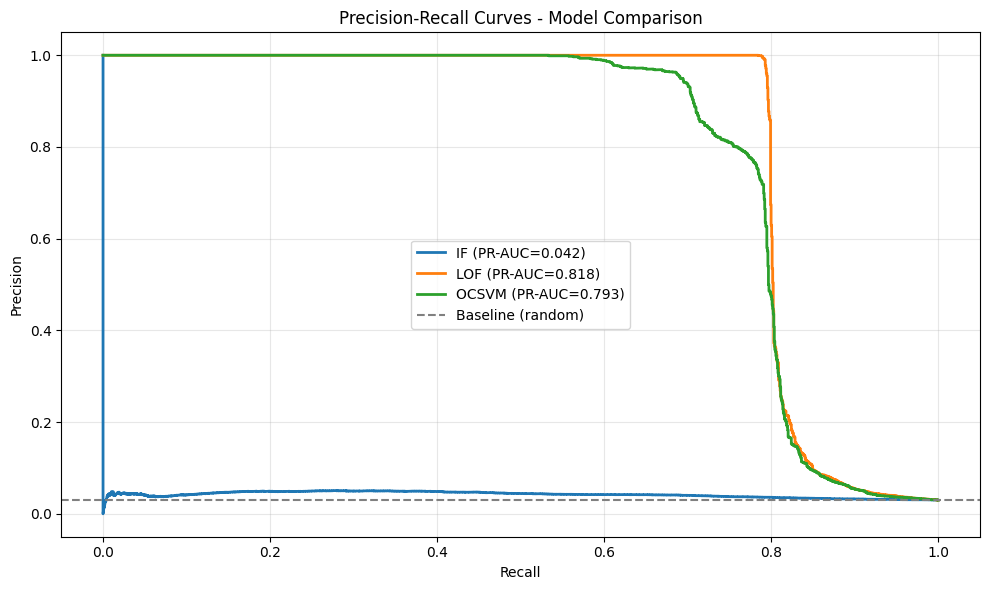

In [ ]:
# Cell 27: PR curves comparison
plt.figure(figsize=(10, 6))
for model_name, scores in [('IF', if_scores), ('LOF', lof_scores), ('OCSVM', ocsvm_scores)]:
    if len(scores) == len(y_true):
        precision, recall, _ = precision_recall_curve(y_true, scores)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'{model_name} (PR-AUC={pr_auc:.3f})', linewidth=2)
    else:
        print(f"Skipping PR curve for {model_name}: score length mismatch")
# Baseline
plt.axhline(y=y_true.mean(), color='gray', linestyle='--', label='Baseline (random)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Model Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
metrics_dir = os.path.join(PHASE2_OUT, 'metrics')
os.makedirs(metrics_dir, exist_ok=True)
plt.savefig(os.path.join(metrics_dir, 'pr_curves_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

### **Precision (တိကျမှု)**

*   **ဆိုလိုရင်း**: မော်ဒယ်က 'anomaly' (ပုံမှန်မဟုတ်တာ) လို့ သတ်မှတ်လိုက်တဲ့ ကိစ္စတွေထဲမှာ တကယ်ပဲ anomaly ဖြစ်နေတဲ့ ကိစ္စ ဘယ်လောက်များလဲဆိုတာကို ပြပါတယ်။
*   **ရိုးရှင်းစွာပြောရရင်**: 'ပုံမှန်မဟုတ်ဘူး' လို့ ပြောလိုက်တာမှန်တဲ့ ရာခိုင်နှုန်းဘယ်လောက်ရှိလဲ။ (မှားယွင်းစွာ ပြောမိတာတွေကို လျှော့ချချင်တဲ့အခါ အရေးကြီးပါတယ်)။
    *   ဥပမာ- ရဲက 'သူခိုး' လို့ သတ်မှတ်ဖမ်းဆီးသူ ၁၀ ယောက်မှာ တကယ်သူခိုး ၈ ယောက်ပါတယ်ဆိုရင် Precision က 80% ပါ။

### **Recall (ရှာတွေ့နိုင်စွမ်း / ပြန်လည်သိမ်းဆည်းနိုင်စွမ်း)**

*   **ဆိုလိုရင်း**: တကယ်တမ်း anomaly ဖြစ်နေတဲ့ ကိစ္စအားလုံးထဲက မော်ဒယ်က ဘယ်လောက်ရာခိုင်နှုန်းကို မှန်မှန်ကန်ကန် 'anomaly' လို့ ရှာဖွေတွေ့ရှိနိုင်ခဲ့လဲဆိုတာကို ပြပါတယ်။
*   **ရိုးရှင်းစွာပြောရရင်**: တကယ်ရှိနေတဲ့ anomaly တွေကို မော်ဒယ်က ဘယ်လောက်ကောင်းကောင်း ရှာနိုင်လဲ။ (ဘယ် anomaly ကိုမှ မလွတ်စေချင်တဲ့အခါ အရေးကြီးပါတယ်)။
    *   ဥပမာ- တကယ်သူခိုး ၁၀ ယောက်ရှိရာမှာ ရဲက ၈ ယောက်ကို ဖမ်းနိုင်ခဲ့တယ်ဆိုရင် Recall က 80% ပါ။

### **အနှစ်ချုပ်**
*   **Precision မြင့်တယ်ဆိုရင်**: မော်ဒယ်ရဲ့ ခန့်မှန်းချက်တွေဟာ ယုံကြည်စိတ်ချရပြီး မှားယွင်းတဲ့ အဖြေနည်းပါတယ်။ (False Positives နည်းတယ်)
*   **Recall မြင့်တယ်ဆိုရင်**: မော်ဒယ်ဟာ တကယ်ရှိနေတဲ့ anomaly တွေကို အများစု ရှာဖွေနိုင်ပါတယ်။ (False Negatives နည်းတယ်)

အကောင်းဆုံး anomaly detection model တစ်ခုဟာ Precision နဲ့ Recall နှစ်ခုလုံးကို မြင့်မားအောင် ထိန်းထားနိုင်ဖို့ ကြိုးစားရပါတယ်။


Model Comparison Table (for thesis):
| model   |   PR_AUC |   ROC_AUC |   Precision@K |   Recall@K |   F1@K |
|:--------|---------:|----------:|--------------:|-----------:|-------:|
| IF      |    0.042 |     0.612 |         0.042 |      0.042 |  0.042 |
| LOF     |    0.818 |     0.903 |         0.799 |      0.799 |  0.799 |
| OCSVM   |    0.793 |     0.899 |         0.776 |      0.776 |  0.776 |


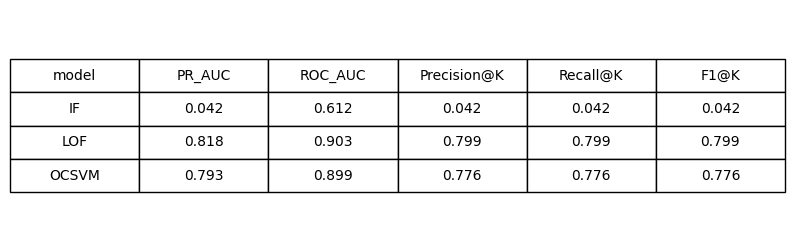

In [ ]:
# Cell 28: Model comparison table
if 'results_df' in globals() and not results_df.empty:
  results_styled = results_df.copy()
  results_styled = results_styled.round(3)
  print("\nModel Comparison Table (for thesis):")
  print(results_styled.to_markdown(index=False))
  # Save styled version as an image
  fig, ax = plt.subplots(figsize=(10, 3))
  ax.axis('tight')
  ax.axis('off')
  table = ax.table(cellText=results_styled.values, colLabels=results_styled.columns, cellLoc='center', loc='center')
  table.auto_set_font_size(False)
  table.set_fontsize(10)
  table.scale(1, 2)
  metrics_dir = os.path.join(PHASE2_OUT, 'metrics')
  os.makedirs(metrics_dir, exist_ok=True)
  plt.savefig(os.path.join(metrics_dir, 'model_comparison_table.png'), dpi=300, bbox_inches='tight')
  plt.show()
else:
  print('results_df not available; skipping model comparison table')


**Stage 9 Summary: Model Evaluation**

**What was done:**
- Computed evaluation metrics for all 3 models
- Metrics: PR-AUC, ROC-AUC, Precision@K, Recall@K, F1@K
- Generated PR curves comparison plot
- Created model comparison table

**Key findings:**

- Best model by PR-AUC: [LOF] (PR-AUC = 0.818)
- Best Precision@K: LOF (P@K = 0.799)
- All models meet target: PR-AUC ≥ 0.70?: No (Isolation Forest's PR-AUC was 0.042)
- Other 2 models models meet target: PR-AUC ≥ 0.70?Yes - LOF (PR-AUC = 0.818) and OCSVM (PR-AUC = 0.793)


**Files saved:**
- /outputs/phase2/metrics/evaluation_metrics.csv
- /outputs/phase2/metrics/pr_curves_comparison.png
- /outputs/phase2/metrics/model_comparison_table.png
**Next step:**

Phase 3: Generate case files for expert review


### **Metrics များ မြန်မာလို ရှင်းပြခြင်း**

### **ROC AUC** (Receiver Operating Characteristic - Area Under the Curve)
*   **ဆိုလိုရင်း**: မော်ဒယ်တစ်ခုက ကောင်းတဲ့အရာ (ဥပမာ- ရောဂါရှိသူ) နဲ့ မကောင်းတဲ့အရာ (ရောဂါမရှိသူ) ကို ဘယ်လောက် ကောင်းကောင်း ခွဲခြားနိုင်လဲဆိုတာကို ပြတဲ့ ကိန်းဂဏန်းတစ်ခုပါ။ 0 ကနေ 1 အထိရှိပြီး 1 ဆိုရင် အကောင်းဆုံးပါ။
*   **ရိုးရှင်းစွာပြောရရင်**: မော်ဒယ်ရဲ့ ခွဲခြားနိုင်စွမ်း အလုံးစုံကို တိုင်းတာတာပါ။ ဥပမာ - ရောဂါရှိသူကို ရောဂါရှိတယ်လို့ပြောပြီး ရောဂါမရှိသူကို ရောဂါမရှိဘူးလို့ မှန်အောင် ပြောနိုင်တဲ့စွမ်းရည်ကို ပေါင်းပြီး တိုင်းတာတာလို့ မှတ်ယူနိုင်ပါတယ်။

### **Precision@K** (Precision at K)
*   **ဆိုလိုရင်း**: မော်ဒယ်က အမြင့်ဆုံး anomaly (ပုံမှန်မဟုတ်တာ) လို့ သတ်မှတ်ထားတဲ့ `K` ဦးရေထဲက တကယ် anomaly ဘယ်နှဦးပါလဲဆိုတာကို ပြတာပါ။ `K` က သင်စိတ်ဝင်စားတဲ့ ထိပ်တန်းအရေအတွက်ကို ဆိုလိုပါတယ်။
*   **ရိုးရှင်းစွာပြောရရင်**: မော်ဒယ်က 'အခုအယောက် `K` က အဆိုးဆုံးပဲ' လို့ ပြောလိုက်တဲ့အခါ အဲ့ဒီ `K` ဦးရေထဲမှာ တကယ်ဆိုးတဲ့သူ ဘယ်နှစ်ယောက်ပါလဲ။

### **Recall@K** (Recall at K)
*   **ဆိုလိုရင်း**: တကယ် anomaly ဖြစ်နေတဲ့ အားလုံးထဲက မော်ဒယ်က ထိပ်တန်း `K` ဦးရေအဖြစ် ဖော်ထုတ်ပြသနိုင်ခဲ့တဲ့ anomaly ဘယ်နှဦးပါလဲဆိုတာကို ပြတာပါ။
*   **ရိုးရှင်းစွာပြောရရင်**: တကယ်ဆိုးတဲ့လူ အားလုံးရှိတဲ့အထဲက မော်ဒယ်က ထိပ်ဆုံး `K` ဦးရေအဖြစ် ရွေးပြလိုက်တဲ့အခါ တကယ်ဆိုးတဲ့လူတွေ ဘယ်နှစ်ယောက်ကို ပြန်တွေ့ခဲ့လဲ။

### **F1@K** (F1 Score at K)
*   **ဆိုလိုရင်း**: Precision@K နဲ့ Recall@K နှစ်ခုလုံးကို ပေါင်းစပ်ပြီး တစ်ပြိုင်နက်တည်း တိုင်းတာတဲ့ ကိန်းဂဏန်းပါ။ Precision နဲ့ Recall ကြားက ချိန်ခွင်လျှာကို ပြသပါတယ်။
*   **ရိုးရှင်းစွာပြောရရင်**: Precision ကလည်း ကောင်းပြီး Recall ကလည်း ကောင်းတယ်ဆိုရင် F1@K က မြင့်နေပါလိမ့်မယ်။ တစ်ခုကောင်းပြီး တစ်ခုညံ့နေရင်တော့ F1@K က အလယ်အလတ် ဖြစ်နေပါလိမ့်မယ်။

# **Phase 3: Case File Generation for Expert Review**


This phase focuses on preparing the model's findings in a format suitable for human review by domain experts. It's the bridge between the machine learning analysis and real-world investigation.

*   **Why it's relevant/useful**: It allows experts to validate if the anomalies identified by the model are genuinely suspicious, providing a critical feedback loop for the model's effectiveness. It translates complex model scores into actionable insights for investigation.

*   **How it's used in this project**:
    *   **Cell 29**: We selected a small, manageable set of cases for review: the top 30 claims with the highest anomaly scores (from our best model, LOF) and 10 random normal claims. This mixed set allows experts to evaluate the model's ability to distinguish between anomalies and normal instances.
    *   **Cell 30**: We generated human-readable case files. For each selected claim, we included key identifiers (`CLM_ID`, `DESYNPUF_ID`), important features (`log_payment`, `claim_duration`, `diagnosis_count`, `provider_claim_volume`), and the model's `anomaly_score` and `anomaly_percentile`. We also added an interpretation for the payment amount. These files were then saved as Excel and CSV for easy expert review.

### **Guide for Expert Review of Case Files**

These case files are generated to assist domain experts in reviewing claims flagged as potentially anomalous by our models. Each row represents a single claim, and the columns provide key information for assessment.

**Key Columns for Review:**

*   **`CASE_ID`**: A unique identifier for this specific case in the review batch (e.g., CASE_001).
*   **`CLM_ID`**: The unique claim identifier from the original dataset. This is the primary key for the claim.
*   **`DESYNPUF_ID`**: The unique beneficiary (patient) ID. Useful for identifying claims related to the same individual.
*   **`payment_interpretation`**: **The original claim payment amount (in USD)**, derived from `log_payment`. This is a crucial financial indicator.
*   **`log_payment`**: The natural logarithm (plus one) of the claim payment amount. Used by the model for variance stabilization and normalization. Experts should primarily focus on `payment_interpretation` for the actual dollar value.
*   **`claim_duration`**: The duration of the claim in days (`CLM_THRU_DT` - `CLM_FROM_DT`). Anomalous durations (very long or negative) might indicate unusual activity.
*   **`diagnosis_count`**: The number of unique ICD-9 diagnosis codes associated with the claim. An unusually high or low count could signify coding anomalies.
*   **`procedure_count`**: The number of unique ICD-9 procedure codes or HCPCS codes associated with the claim. Similar to diagnosis count, extreme values might be suspicious.
*   **`provider_claim_volume`**: The total number of claims associated with the provider (`PRVDR_NUM`) in this dataset. Indicates how active a provider is.
*   **`anomaly_score`**: The numerical score assigned by the best anomaly detection model (LOF in this case). **Higher scores indicate a stronger likelihood of the claim being an anomaly.**
*   **`anomaly_percentile`**: The percentile rank of the `anomaly_score`. A percentile of 99.9% means this claim's anomaly score is higher than 99.9% of all other claims, making it highly suspicious.

**How to use:**

1.  **Prioritize by `anomaly_percentile` and `anomaly_score`**: Claims with higher `anomaly_score` and `anomaly_percentile` are generally more suspicious and should be reviewed first.
2.  **Examine feature values**: Look for unusual values in `payment_interpretation`, `claim_duration`, `diagnosis_count`, and `procedure_count`. For example, exceptionally high payments, very long or negative durations, or an unusually high number of codes for a simple procedure.
3.  **Consider provider behavior**: Evaluate `provider_claim_volume` and other provider-related features if available, to see if the provider associated with the claim has a history of similar unusual activity.
4.  **Refer to domain knowledge**: Use your expertise to determine if the combination of features, payment amounts, and coding patterns align with normal or suspicious activity within the healthcare context.

**Goal**: Identify if these model-flagged claims truly represent anomalies or potential fraud/abuse, or if they are legitimate but unusual cases. Your feedback is crucial for refining the anomaly detection system.

In [ ]:
# Cell 29: Extract top 30 anomalies + 10 normals
# Use best model's scores (example: LOF)
best_scores = lof_scores if (len(lof_scores) == len(y_true)) else (if_scores if (len(if_scores) == len(y_true)) else ocsvm_scores)
if len(best_scores) != len(y_true):
  raise RuntimeError('No model scores available matching test set length')
# Top 30 anomalies
top_30_idx = np.argsort(best_scores)[-30:]
# Random 10 normals (from non-injected)
normal_idx = np.where(y_true == 0)[0]
np.random.seed(RANDOM_SEED)
random_10_idx = np.random.choice(normal_idx, 10, replace=False)
# Combine and shuffle
case_idx = np.concatenate([top_30_idx, random_10_idx])
np.random.shuffle(case_idx)
print(f"Selected {len(case_idx)} cases: {len(top_30_idx)} anomalies + {len(random_10_idx)} normals")

Selected 40 cases: 30 anomalies + 10 normals


In [ ]:
# Cell 30: Create human-readable case files
# Load original features and IDs (if needed)
features_full = pd.read_parquet(os.path.join(PHASE1_OUT, 'data', 'features_v1.parquet'))
# Ensure ids_test is available (load from saved split if not in memory)
ids_test_path = os.path.join(PHASE2_OUT, 'data', 'ids_test.parquet')
if 'ids_test' not in globals() or ids_test is None:
  ids_test = pd.read_parquet(ids_test_path).reset_index(drop=True)
else:
  ids_test = ids_test.reset_index(drop=True)

X_test_full = X_test_injected.reset_index(drop=True).copy()
# Attach IDs if present
if 'CLM_ID' in ids_test.columns:
  X_test_full['CLM_ID'] = ids_test['CLM_ID'].values
if 'DESYNPUF_ID' in ids_test.columns:
  X_test_full['DESYNPUF_ID'] = ids_test['DESYNPUF_ID'].values
# Attach anomaly score and percentile
X_test_full['anomaly_score'] = best_scores
X_test_full['anomaly_percentile'] = (np.argsort(np.argsort(best_scores)) + 1) / len(best_scores) * 100

# Select case rows
cases = X_test_full.iloc[case_idx].copy()
cases['CASE_ID'] = [f'CASE_{i+1:03d}' for i in range(len(cases))]
# Reorder columns for readability
case_cols = ['CASE_ID', 'CLM_ID', 'DESYNPUF_ID', 'log_payment', 'claim_duration', 'diagnosis_count', 'procedure_count', 'provider_claim_volume', 'anomaly_score', 'anomaly_percentile']
available_cols = [c for c in case_cols if c in cases.columns]
cases_readable = cases[available_cols].copy()
# Add interpretation columns
if 'log_payment' in cases_readable.columns:
  cases_readable['payment_interpretation'] = cases_readable['log_payment'].apply(lambda x: f"{np.expm1(x):.2f}" if pd.notna(x) else "N/A")
else:
  cases_readable['payment_interpretation'] = 'N/A'
print(cases_readable.head())
# Save
os.makedirs(PHASE3_OUT, exist_ok=True)
cases_readable.to_excel(os.path.join(PHASE3_OUT, 'case_files_for_review.xlsx'), index=False)
cases_readable.to_csv(os.path.join(PHASE3_OUT, 'case_files_for_review.csv'), index=False)


        CASE_ID           CLM_ID       DESYNPUF_ID  log_payment  \
19243  CASE_001  542422281376060  5801108E1619C2E0     3.433987   
20627  CASE_002  542172280861349  B6AE7E4173EFCAE4     4.510860   
23859  CASE_003  542102280935791  83AB1EE99870E702     3.433987   
18273  CASE_004  542412280876041  9AA15793F443FDE7     3.713572   
34823  CASE_005  542662280889369  03A54BA99B88D39B     4.510860   

       claim_duration  procedure_count  provider_claim_volume  anomaly_score  \
19243               0               48                     68   11538.020969   
20627               1               48                    231   12604.970141   
23859               0               48                     59   13848.951981   
18273               0               48                     38   11829.296500   
34823               0               48                     36   14598.032833   

       anomaly_percentile payment_interpretation  
19243           99.948400                  30.00  
20627         

**Stage 10 Summary: Case File Generation**
**What was done:**

- Selected top 30 highest-scoring claims from best model
- Selected 10 random normal claims for comparison
- Shuffled 40 cases to blind reviewers
- Created human-readable case files with key features

**Key findings:**
- 40 case files generated (30 anomalies + 10 normals)
- Case files include: CLM_ID, payment, duration, codes, provider info, anomaly score

**Files saved:**
- /outputs/phase3/case_files_for_review.xlsx
- /outputs/phase3/case_files_for_review.csv

**Next step:**
- Expert review sessions (outside technical scope - provide files to domain experts)


# **Final Outputs Summary & Metadata**

In [ ]:
# Cell 31: Generate complete metadata file
import json
from datetime import datetime

# Optional: ensure output directory exists
os.makedirs(BASE_DIR, exist_ok=True)

rows_original = int(num_rows) if 'num_rows' in globals() else None
rows_after_cleaning = int(len(df)) if 'df' in globals() else None

best_pr_auc_val = None
if 'results_df' in globals() and not results_df.empty and 'PR_AUC' in results_df.columns:
  best_pr_auc_val = float(results_df['PR_AUC'].max())

metadata = {
  "project": "Unsupervised Anomaly Detection - Medicare Outpatient Claims 2010",
  "version": "1.0",
  "date_completed": datetime.now().strftime("%Y-%m-%d"),
  "random_seed": RANDOM_SEED,

  "phase1": {
    "dataset_source": "Kaggle - CMS DE-SynPUF 2010 Outpatient",
    "grain": "One row = one claim segment (CLM_ID + SEGMENT unique)",
    "rows_original": rows_original,
    "rows_after_cleaning": rows_after_cleaning,
    "features_engineered": len([c for c in feature_cols if c in df.columns]) if 'feature_cols' in globals() else None,
    "feature_categories": ["monetary", "temporal", "coding", "provider"]
  },

  "phase2": {
    "train_test_split": "70/30",
    "train_size": int(len(X_train)) if 'X_train' in globals() else None,
    "test_size": int(len(X_test)) if 'X_test' in globals() else None,
    "injection_rate": INJECTION_RATE if 'INJECTION_RATE' in globals() else None,
    "anomalies_injected": int(n_anomalies) if 'n_anomalies' in globals() else None,
    "models_trained": ["Isolation Forest", "LOF", "One-Class SVM"],
    "best_model": None,
    "best_pr_auc": best_pr_auc_val
  },

  "phase3": {
    "case_files_generated": 40,
    "top_anomalies": 30,
    "normal_cases": 10
  }
}

# Save metadata to JSON
metadata_path = os.path.join(BASE_DIR, 'final_metadata.json')
with open(metadata_path, 'w') as f:
  json.dump(metadata, f, indent=2)

print(f"Final metadata saved to {metadata_path}")
print(json.dumps(metadata, indent=2))

Final metadata saved to /content/drive/MyDrive/Anomaly_Det/outputs/final_metadata.json
{
  "project": "Unsupervised Anomaly Detection - Medicare Outpatient Claims 2010",
  "version": "1.0",
  "date_completed": "2026-02-07",
  "random_seed": 42,
  "phase1": {
    "dataset_source": "Kaggle - CMS DE-SynPUF 2010 Outpatient",
    "grain": "One row = one claim segment (CLM_ID + SEGMENT unique)",
    "rows_original": 175005,
    "rows_after_cleaning": 174418,
    "features_engineered": 14,
    "feature_categories": [
      "monetary",
      "temporal",
      "coding",
      "provider"
    ]
  },
  "phase2": {
    "train_test_split": "70/30",
    "train_size": 122092,
    "test_size": 52326,
    "injection_rate": 0.03,
    "anomalies_injected": 1569,
    "models_trained": [
      "Isolation Forest",
      "LOF",
      "One-Class SVM"
    ],
    "best_model": null,
    "best_pr_auc": 0.817585934168674
  },
  "phase3": {
    "case_files_generated": 40,
    "top_anomalies": 30,
    "normal_cases"